# Лабораторная работа: Нечёткая логика — реализация нечёткой системы в Python

**Дисциплина:** Искусственный интеллект в средствах защиты информации

**Цель работы:** Реализовать нечёткую систему поддержки принятия решений в среде Google Colab с использованием библиотеки `simpful`, провести анализ чувствительности и визуализировать поверхность отклика.

---

### Структура оценивания

**Базовые задания (80 баллов):**

| Задание | Балл | Описание |
|---------|------|----------|
| Б1 | 15 | Реализация подсистемы 1 варианта |
| Б2 | 15 | Реализация подсистемы 2 варианта |
| Б3 | 20 | Каскадная система (подсистема 3) |
| Б4 | 10 | 3D-поверхность для каждой подсистемы |
| Б5 | 5 | Тепловая карта |
| Б6 | 10 | Тестирование на 5+ наборах входов |
| Б7 | 5 | Выводы |

**Продвинутые задания (до +35 баллов):**

| Задание | Балл | Описание |
|---------|------|----------|
| П1 | 10 | Сравнение Мамдани vs Сугено |
| П2 | 10 | Исследование влияния формы MF |
| П3 | 15 | Расширение до 3-х входных переменных |

---

## Блок 1. Установка и импорт библиотек

In [1]:
# Ячейка 1: Установка библиотек
!pip install simpful matplotlib numpy -q
print("\n✅ Библиотеки установлены")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai


✅ Библиотеки установлены


In [2]:
# Ячейка 2: Импорт
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import simpful as sf
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"simpful: {sf.__path__[0]}")
print("✅ Все библиотеки импортированы")

simpful: /usr/local/lib/python3.12/dist-packages/simpful
✅ Все библиотеки импортированы


---

## Блок 2. Визуализация функций принадлежности

### Теоретическая справка

**Функция принадлежности** (membership function, MF) определяет, в какой степени каждое значение переменной принадлежит нечёткому множеству (терму). Основные типы:

| Тип | Параметры | Особенности |
|-----|-----------|-------------|
| Треугольная | (a, b, c) | Простая, наиболее распространённая |
| Трапецеидальная | (a, b, c, d) | «Зона уверенности» μ = 1 |
| Гауссова | (μ, σ) | Гладкая, симметричная |

In [3]:
# Ячейка 3: Вспомогательные функции для визуализации

def triangular_mf(x, a, b, c):
    """
    Треугольная функция принадлежности MF(a, b, c).
    a — левая граница, b — вершина, c — правая граница.
    """
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x)
    if b != a:
        mask = (x > a) & (x <= b)
        result[mask] = (x[mask] - a) / (b - a)
    else:
        result[x == a] = 1.0
    if c != b:
        mask = (x > b) & (x < c)
        result[mask] = (c - x[mask]) / (c - b)
    else:
        result[x == c] = 1.0
    result[x == b] = 1.0
    return result


def gaussian_mf_func(x, c, sigma):
    """Гауссова MF: μ(x) = exp(-((x-c)/σ)²)"""
    return np.exp(-((np.asarray(x, dtype=float) - c) / sigma) ** 2)


def trapezoidal_mf_func(x, a, b, c, d):
    """Трапецеидальная MF(a, b, c, d)."""
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x)
    if b != a:
        mask = (x > a) & (x <= b)
        result[mask] = (x[mask] - a) / (b - a)
    mask_top = (x >= b) & (x <= c)
    result[mask_top] = 1.0
    if d != c:
        mask = (x > c) & (x < d)
        result[mask] = (d - x[mask]) / (d - c)
    return result


def plot_membership_functions(variable_name, universe, terms_dict, xlabel='x'):
    """
    Визуализация функций принадлежности лингвистической переменной.
    terms_dict: {имя_терма: (тип, *параметры)}
      тип: 'tri' для треугольной, 'gauss' для гауссовой, 'trap' для трапецеидальной
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    
    for i, (name, spec) in enumerate(terms_dict.items()):
        mf_type = spec[0]
        if mf_type == 'tri':
            values = triangular_mf(universe, spec[1], spec[2], spec[3])
        elif mf_type == 'gauss':
            values = gaussian_mf_func(universe, spec[1], spec[2])
        elif mf_type == 'trap':
            values = trapezoidal_mf_func(universe, spec[1], spec[2], spec[3], spec[4])
        else:
            values = triangular_mf(universe, spec[1], spec[2], spec[3])
        
        ax.plot(universe, values, linewidth=2.5, label=name, color=colors[i % len(colors)])
        ax.fill_between(universe, values, alpha=0.12, color=colors[i % len(colors)])
    
    ax.set_title(f'Функции принадлежности: «{variable_name}»', fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('μ(x)', fontsize=12)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=11, loc='upper right')
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

print("✅ Вспомогательные функции определены")

✅ Вспомогательные функции определены


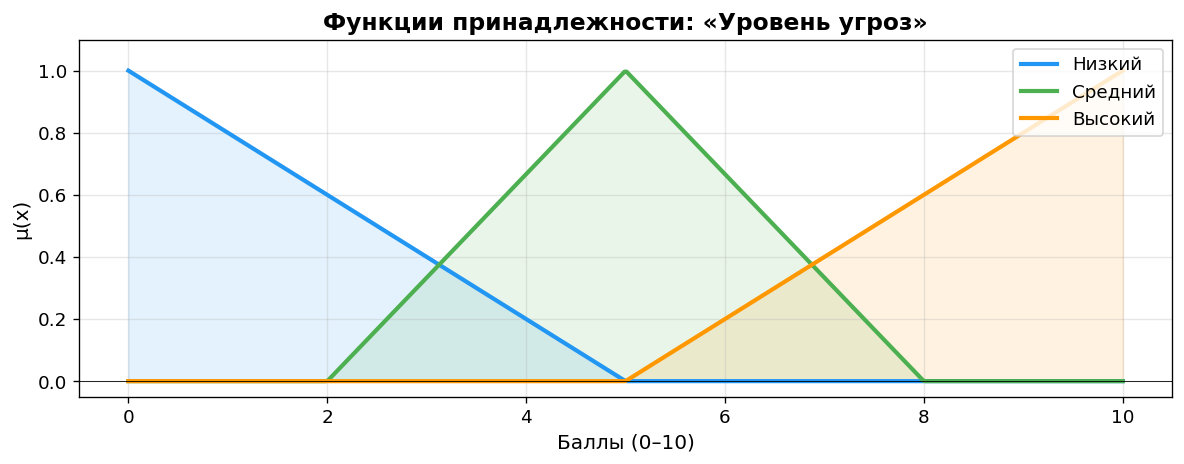

In [4]:
# Ячейка 4: Пример — визуализация «Уровень угроз»

universe_x = np.linspace(0, 10, 500)

terms_threats = {
    'Низкий':  ('tri', 0, 0, 5),
    'Средний': ('tri', 2, 5, 8),
    'Высокий': ('tri', 5, 10, 10)
}

plot_membership_functions('Уровень угроз', universe_x, terms_threats, xlabel='Баллы (0–10)')

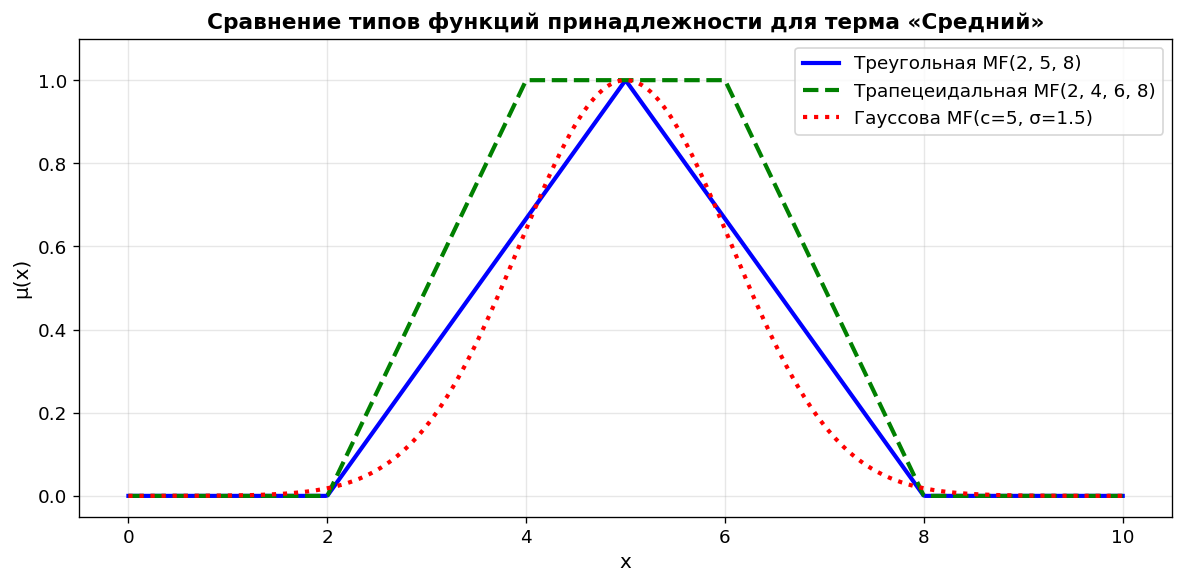

💡 Треугольная — простая, с острой вершиной
   Трапецеидальная — с 'зоной уверенности' (плато μ=1)
   Гауссова — гладкая, без резких изломов


In [5]:
# Ячейка 5: Сравнение трёх типов MF для одного терма «Средний»

x = np.linspace(0, 10, 500)

fig, ax = plt.subplots(figsize=(10, 5))

# Треугольная
ax.plot(x, triangular_mf(x, 2, 5, 8), 'b-', linewidth=2.5, label='Треугольная MF(2, 5, 8)')
# Трапецеидальная
ax.plot(x, trapezoidal_mf_func(x, 2, 4, 6, 8), 'g--', linewidth=2.5, label='Трапецеидальная MF(2, 4, 6, 8)')
# Гауссова
ax.plot(x, gaussian_mf_func(x, 5, 1.5), 'r:', linewidth=2.5, label='Гауссова MF(c=5, σ=1.5)')

ax.set_title('Сравнение типов функций принадлежности для терма «Средний»',
            fontsize=13, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('μ(x)', fontsize=12)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("💡 Треугольная — простая, с острой вершиной")
print("   Трапецеидальная — с 'зоной уверенности' (плато μ=1)")
print("   Гауссова — гладкая, без резких изломов")

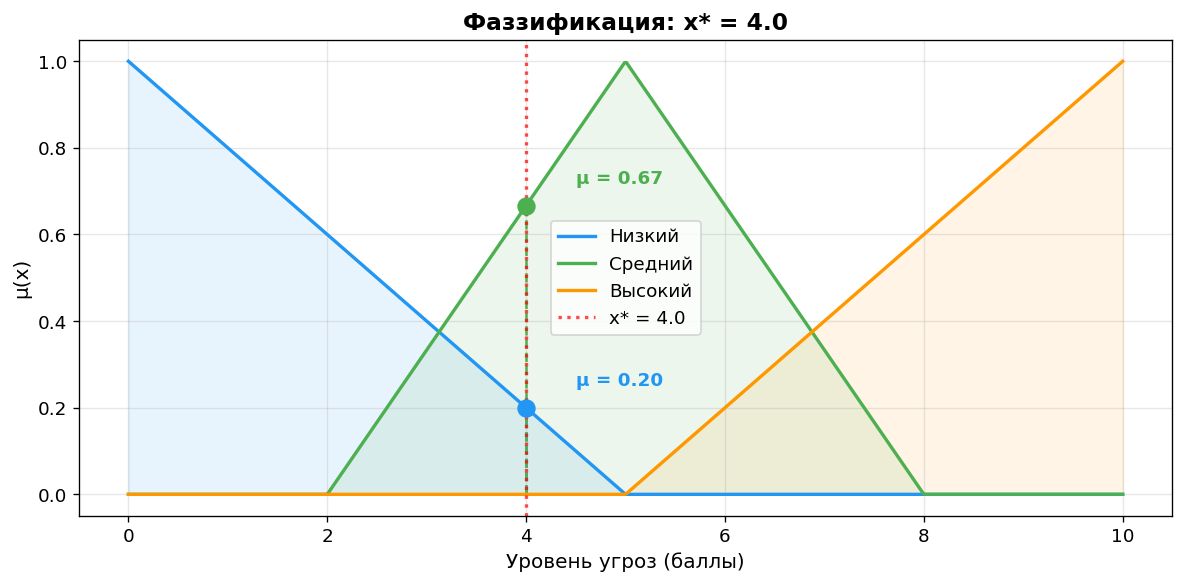

Результат фаззификации для x* = 4.0:
  μ_Низкий(4.0) = 0.2000
  μ_Средний(4.0) = 0.6667
  μ_Высокий(4.0) = 0.0000


In [6]:
# Ячейка 6: Демонстрация фаззификации

x_star = 4.0  # конкретное входное значение

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
colors = {'Низкий': '#2196F3', 'Средний': '#4CAF50', 'Высокий': '#FF9800'}
params = {'Низкий': (0, 0, 5), 'Средний': (2, 5, 8), 'Высокий': (5, 10, 10)}

for name, (a, b, c) in params.items():
    values = triangular_mf(universe_x, a, b, c)
    ax.plot(universe_x, values, linewidth=2, label=name, color=colors[name])
    ax.fill_between(universe_x, values, alpha=0.1, color=colors[name])
    
    mu = triangular_mf(np.array([x_star]), a, b, c)[0]
    if mu > 0:
        ax.plot([x_star, x_star], [0, mu], '--', color=colors[name], linewidth=1.5)
        ax.plot(x_star, mu, 'o', color=colors[name], markersize=10, zorder=5)
        ax.annotate(f'μ = {mu:.2f}', xy=(x_star, mu),
                   xytext=(x_star + 0.5, mu + 0.05),
                   fontsize=11, fontweight='bold', color=colors[name])

ax.axvline(x=x_star, color='red', linewidth=2, linestyle=':', alpha=0.7, label=f'x* = {x_star}')
ax.set_title(f'Фаззификация: x* = {x_star}', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень угроз (баллы)', fontsize=12)
ax.set_ylabel('μ(x)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Результат фаззификации для x* = {x_star}:")
for name, (a, b, c) in params.items():
    mu = triangular_mf(np.array([x_star]), a, b, c)[0]
    print(f"  μ_{name}({x_star}) = {mu:.4f}")

---

## Блок 3. Определение нечёткой системы с помощью simpful

### Теоретическая справка

Библиотека **simpful** позволяет задавать нечёткие системы на естественном языке:
```python
"IF (Переменная IS Терм) AND (Переменная2 IS Терм2) THEN (Выход IS Терм3)"
```

Поддерживаемые операции в правилах:
- `AND` — пересечение (min)
- `OR` — объединение (max)
- `IS NOT` — отрицание

In [7]:
# Ячейка 7: Создание демонстрационной нечёткой системы
# Система из методички: Оценка затрат на модернизацию СЗИ

FS_demo = sf.FuzzySystem(show_banner=False)

# === Входная переменная 1: Уровень угроз ===
T1 = sf.AutoTriangle(3, terms=['Низкий', 'Средний', 'Высокий'],
                     universe_of_discourse=[0, 10])
FS_demo.add_linguistic_variable("УровеньУгроз", T1)

# === Входная переменная 2: Уязвимость ресурсов ===
V1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=6), term="Невысокая")
V2 = sf.FuzzySet(function=sf.Triangular_MF(a=4, b=10, c=10), term="Высокая")
FS_demo.add_linguistic_variable("Уязвимость",
    sf.LinguisticVariable([V1, V2], universe_of_discourse=[0, 10]))

# === Выходная переменная: Затраты на модернизацию ===
Z1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=60), term="Низкие")
Z2 = sf.FuzzySet(function=sf.Triangular_MF(a=40, b=100, c=100), term="Высокие")
FS_demo.add_linguistic_variable("Затраты",
    sf.LinguisticVariable([Z1, Z2], universe_of_discourse=[0, 100]))

print("✅ Лингвистические переменные определены")
print("\nПеременные системы:")
print("  1. УровеньУгроз [0, 10]: Низкий, Средний, Высокий")
print("  2. Уязвимость [0, 10]: Невысокая, Высокая")
print("  3. Затраты [0, 100]: Низкие, Высокие")

✅ Лингвистические переменные определены

Переменные системы:
  1. УровеньУгроз [0, 10]: Низкий, Средний, Высокий
  2. Уязвимость [0, 10]: Невысокая, Высокая
  3. Затраты [0, 100]: Низкие, Высокие


In [8]:
# Ячейка 8: Определение базы правил

RULE1 = "IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Низкие)"
RULE2 = "IF (УровеньУгроз IS Средний) AND (Уязвимость IS Невысокая) THEN (Затраты IS Высокие)"
RULE3 = "IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Высокие)"
RULE4 = "IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Высокая) THEN (Затраты IS Низкие)"
RULE5 = "IF (УровеньУгроз IS Средний) AND (Уязвимость IS Высокая) THEN (Затраты IS Низкие)"
RULE6 = "IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Высокая) THEN (Затраты IS Высокие)"

FS_demo.add_rules([RULE1, RULE2, RULE3, RULE4, RULE5, RULE6])

print("✅ База правил добавлена (6 правил):\n")
for i, rule in enumerate([RULE1, RULE2, RULE3, RULE4, RULE5, RULE6], 1):
    print(f"  R{i}: {rule}")

print("\n📋 Матрица правил:")
print("  y\\x        | Низкий  | Средний | Высокий")
print("  ────────────┼─────────┼─────────┼────────")
print("  Невысокая   | Низкие  | Высокие | Высокие")
print("  Высокая     | Низкие  | Низкие  | Высокие")

✅ База правил добавлена (6 правил):

  R1: IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Низкие)
  R2: IF (УровеньУгроз IS Средний) AND (Уязвимость IS Невысокая) THEN (Затраты IS Высокие)
  R3: IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Высокие)
  R4: IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Высокая) THEN (Затраты IS Низкие)
  R5: IF (УровеньУгроз IS Средний) AND (Уязвимость IS Высокая) THEN (Затраты IS Низкие)
  R6: IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Высокая) THEN (Затраты IS Высокие)

📋 Матрица правил:
  y\x        | Низкий  | Средний | Высокий
  ────────────┼─────────┼─────────┼────────
  Невысокая   | Низкие  | Высокие | Высокие
  Высокая     | Низкие  | Низкие  | Высокие


In [9]:
# Ячейка 9: Вычисление для конкретных входных значений

FS_demo.set_variable("УровеньУгроз", 4.0)
FS_demo.set_variable("Уязвимость", 3.0)

result = FS_demo.Mamdani_inference(["Затраты"])

print(f"{'═'*50}")
print(f"Входные данные:")
print(f"  Уровень угроз = 4.0")
print(f"  Уязвимость = 3.0")
print(f"\nРезультат (метод Мамдани):")
print(f"  Затраты на модернизацию = {result['Затраты']:.2f}")
print(f"{'═'*50}")
print(f"\n💡 Сравните с ручным расчётом из практической работы (~61.1)")

══════════════════════════════════════════════════
Входные данные:
  Уровень угроз = 4.0
  Уязвимость = 3.0

Результат (метод Мамдани):
  Затраты на модернизацию = 61.16
══════════════════════════════════════════════════

💡 Сравните с ручным расчётом из практической работы (~61.1)


In [10]:
# Ячейка 10: Тестирование на нескольких входах

test_inputs = [
    (2, 2, "Низкие угрозы, низкая уязвимость"),
    (4, 3, "Средне-низкие"),
    (5, 5, "Средние"),
    (7, 8, "Высокие угрозы, высокая уязвимость"),
    (9, 9, "Критические"),
]

print(f"{'Описание':<40} | {'x':>3} | {'y':>3} | {'Затраты':>8}")
print("─" * 65)

for x_val, y_val, desc in test_inputs:
    FS_demo.set_variable("УровеньУгроз", x_val)
    FS_demo.set_variable("Уязвимость", y_val)
    res = FS_demo.Mamdani_inference(["Затраты"])
    print(f"{desc:<40} | {x_val:>3} | {y_val:>3} | {res['Затраты']:>8.2f}")

Описание                                 |   x |   y |  Затраты
─────────────────────────────────────────────────────────────────
Низкие угрозы, низкая уязвимость         |   2 |   2 |    45.11
Средне-низкие                            |   4 |   3 |    61.16
Средние                                  |   5 |   5 |    50.00
Высокие угрозы, высокая уязвимость       |   7 |   8 |    45.11
Критические                              |   9 |   9 |    65.77


---

## Блок 4. Пошаговая визуализация нечёткого вывода

Визуализируем все 4 этапа алгоритма Мамдани:
1. Фаззификация входов
2. Агрегация предпосылок (уровни отсечения α)
3. Композиция (объединение усечённых MF)
4. Дефаззификация (центроид)

In [11]:
# Ячейка 13: Полная визуализация процесса вывода

def visualize_inference_steps(x_val, y_val,
                              terms_x, params_x, universe_x,
                              terms_y, params_y, universe_y,
                              terms_z, params_z, universe_z,
                              rules_table):
    """
    Пошаговая визуализация нечёткого вывода Мамдани.
    
    terms_x/y/z: list of term names
    params_x/y/z: dict {term_name: (a, b, c)} — параметры треугольных MF
    rules_table: list of (x_term, y_term, z_term)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    colors_palette = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    
    # Фаззификация x
    mu_x = {}
    ax = axes[0, 0]
    for i, name in enumerate(terms_x):
        a, b, c = params_x[name]
        vals = triangular_mf(universe_x, a, b, c)
        mu = triangular_mf(np.array([x_val]), a, b, c)[0]
        mu_x[name] = mu
        ax.plot(universe_x, vals, color=colors_palette[i], lw=2, label=f'{name} (μ={mu:.2f})')
        ax.fill_between(universe_x, vals, alpha=0.1, color=colors_palette[i])
        if mu > 0:
            ax.plot([x_val], [mu], 'o', color=colors_palette[i], ms=8)
    ax.axvline(x=x_val, color='red', ls=':', lw=2)
    ax.set_title(f'Шаг 1а: Фаззификация x* = {x_val}', fontweight='bold')
    ax.set_ylabel('μ(x)')
    ax.legend(fontsize=9)
    
    # Фаззификация y
    mu_y = {}
    ax = axes[0, 1]
    for i, name in enumerate(terms_y):
        a, b, c = params_y[name]
        vals = triangular_mf(universe_y, a, b, c)
        mu = triangular_mf(np.array([y_val]), a, b, c)[0]
        mu_y[name] = mu
        ax.plot(universe_y, vals, color=colors_palette[i], lw=2, label=f'{name} (μ={mu:.2f})')
        ax.fill_between(universe_y, vals, alpha=0.1, color=colors_palette[i])
        if mu > 0:
            ax.plot([y_val], [mu], 'o', color=colors_palette[i], ms=8)
    ax.axvline(x=y_val, color='red', ls=':', lw=2)
    ax.set_title(f'Шаг 1б: Фаззификация y* = {y_val}', fontweight='bold')
    ax.legend(fontsize=9)
    
    # Агрегация и усечение
    ax = axes[0, 2]
    result_mf = np.zeros_like(universe_z, dtype=float)
    active_rules = []
    rule_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#795548',
                   '#00BCD4', '#8BC34A', '#E91E63']
    
    for i, (xt, yt, zt) in enumerate(rules_table):
        alpha = min(mu_x.get(xt, 0), mu_y.get(yt, 0))
        if alpha > 0:
            a, b, c = params_z[zt]
            clipped = np.minimum(alpha, triangular_mf(universe_z, a, b, c))
            ax.fill_between(universe_z, clipped, alpha=0.3,
                          color=rule_colors[i % len(rule_colors)],
                          label=f'R{i+1}: α={alpha:.2f} → {zt}')
            result_mf = np.maximum(result_mf, clipped)
            active_rules.append((i+1, xt, yt, zt, alpha))
    
    ax.plot(universe_z, result_mf, 'k-', lw=2.5, label='Результат (max)')
    ax.set_title('Шаги 2–3: Агрегация и композиция', fontweight='bold')
    ax.legend(fontsize=9)
    
    # Дефаззификация
    ax = axes[1, 0]
    ax.fill_between(universe_z, result_mf, alpha=0.4, color='#673AB7')
    ax.plot(universe_z, result_mf, 'k-', lw=2)
    
    z_star = np.sum(universe_z * result_mf) / np.sum(result_mf) if np.sum(result_mf) > 0 else 0
    ax.axvline(x=z_star, color='red', lw=2.5, ls='--')
    ax.plot(z_star, 0, 'v', color='red', ms=15, zorder=5)
    ax.annotate(f'z* = {z_star:.1f}', xy=(z_star, 0.02),
               fontsize=14, fontweight='bold', color='red', ha='center')
    ax.set_title('Шаг 4: Дефаззификация (центроид)', fontweight='bold')
    ax.set_ylabel('μ(z)')
    ax.set_xlabel('z')
    
    # Таблица правил
    ax = axes[1, 1]
    ax.axis('off')
    text = "Активные правила:\n\n"
    for num, xt, yt, zt, alpha in active_rules:
        text += f"R{num}: {xt} ∧ {yt} → {zt}  (α={alpha:.2f})\n"
    text += f"\n{'─'*35}\n"
    text += f"Центроид: z* = {z_star:.1f}"
    ax.text(0.1, 0.9, text, transform=ax.transAxes, fontsize=12,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('Сводка', fontweight='bold')
    
    # Выходные MF
    ax = axes[1, 2]
    for i, name in enumerate(params_z):
        a, b, c = params_z[name]
        ax.plot(universe_z, triangular_mf(universe_z, a, b, c),
               '--', color=colors_palette[i], lw=2, alpha=0.6, label=name)
    ax.plot(universe_z, result_mf, 'k-', lw=2.5, label='Результат')
    ax.axvline(x=z_star, color='red', lw=2, ls='--', alpha=0.7)
    ax.set_title('Выходные MF и результат', fontweight='bold')
    ax.set_xlabel('z')
    ax.legend(fontsize=9)
    
    fig.suptitle(f'Нечёткий вывод Мамдани: x*={x_val}, y*={y_val} → z*={z_star:.1f}',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    return z_star

print("✅ Функция визуализации определена")

✅ Функция визуализации определена


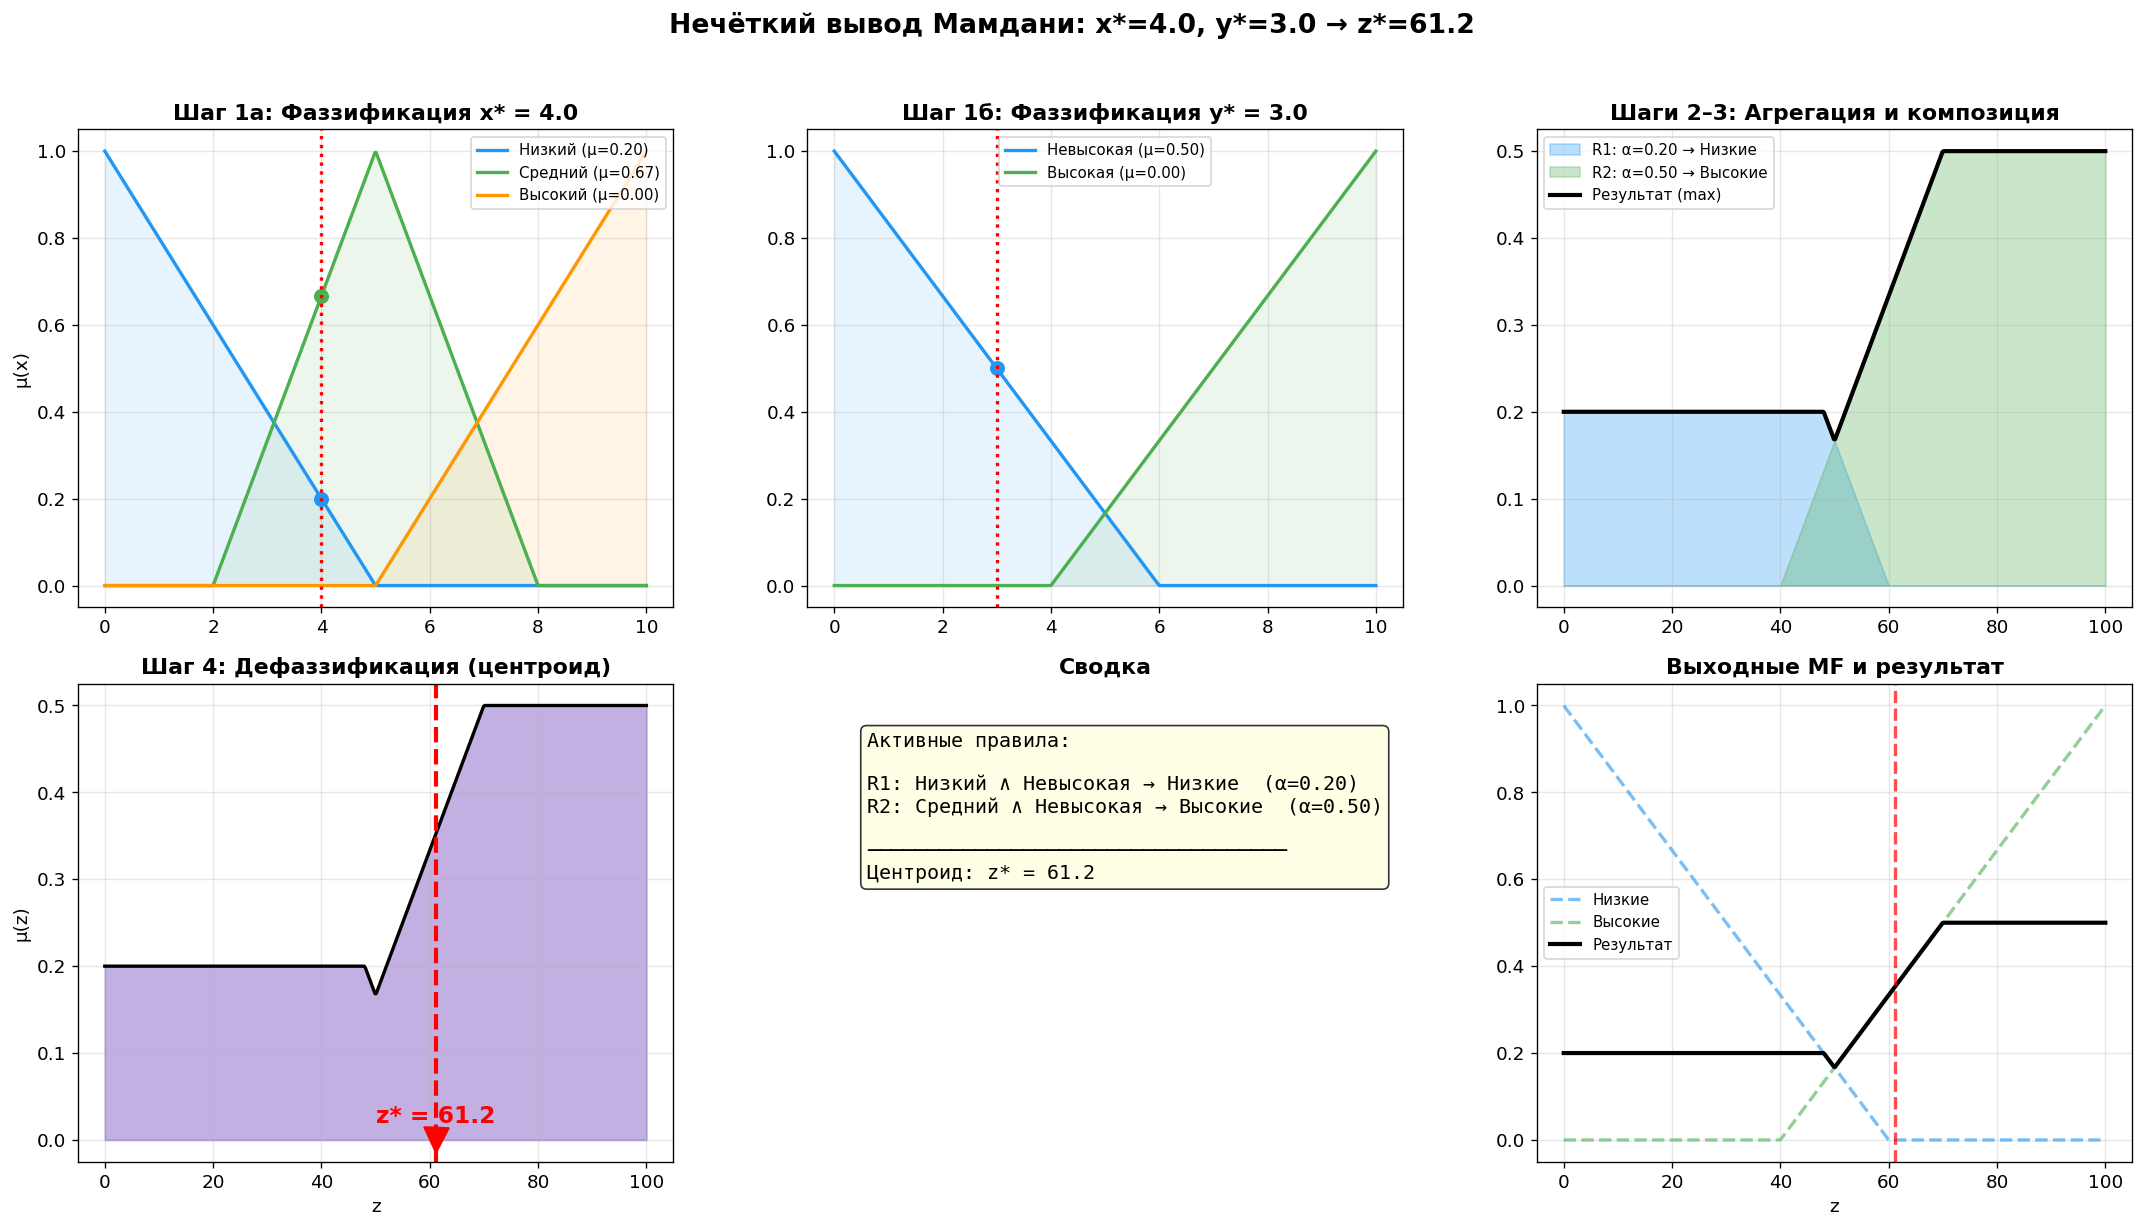

In [12]:
# Ячейка 14: Запуск визуализации для демо-системы

rules_table_demo = [
    ('Низкий', 'Невысокая', 'Низкие'),
    ('Средний', 'Невысокая', 'Высокие'),
    ('Высокий', 'Невысокая', 'Высокие'),
    ('Низкий', 'Высокая', 'Низкие'),
    ('Средний', 'Высокая', 'Низкие'),
    ('Высокий', 'Высокая', 'Высокие'),
]

params_x_demo = {'Низкий': (0, 0, 5), 'Средний': (2, 5, 8), 'Высокий': (5, 10, 10)}
params_y_demo = {'Невысокая': (0, 0, 6), 'Высокая': (4, 10, 10)}
params_z_demo = {'Низкие': (0, 0, 60), 'Высокие': (40, 100, 100)}

z_result = visualize_inference_steps(
    4.0, 3.0,
    terms_x=['Низкий', 'Средний', 'Высокий'], params_x=params_x_demo, universe_x=np.linspace(0, 10, 500),
    terms_y=['Невысокая', 'Высокая'], params_y=params_y_demo, universe_y=np.linspace(0, 10, 500),
    terms_z=['Низкие', 'Высокие'], params_z=params_z_demo, universe_z=np.linspace(0, 100, 500),
    rules_table=rules_table_demo
)

---

## Блок 5. Анализ чувствительности и 3D-поверхность

### Теоретическая справка

**3D-поверхность отклика** показывает, как выход системы зависит от двух входных переменных одновременно. Это позволяет:
- Увидеть общую «ландшафтную» картину поведения системы
- Обнаружить области резких переходов (границы термов)
- Оценить чувствительность к каждому из входов

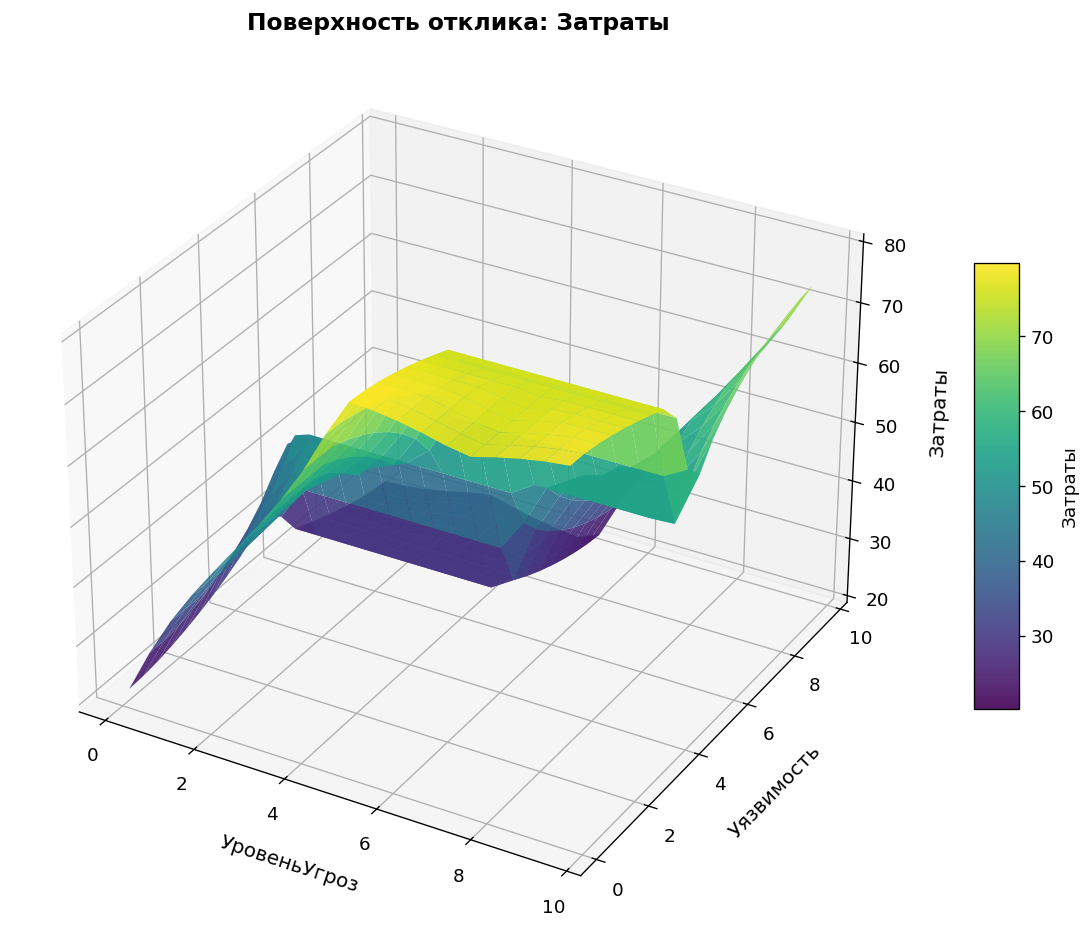

In [13]:
# Ячейка 19: Построение 3D-поверхности отклика

def build_3d_surface(FS, var1_name, var1_range, var2_name, var2_range,
                     output_name, method='Mamdani', step=0.5):
    """
    Построение 3D-поверхности отклика нечёткой системы.
    """
    x_range = np.arange(var1_range[0] + 0.1, var1_range[1], step)
    y_range = np.arange(var2_range[0] + 0.1, var2_range[1], step)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    
    for i in range(len(y_range)):
        for j in range(len(x_range)):
            FS.set_variable(var1_name, float(X[i, j]))
            FS.set_variable(var2_name, float(Y[i, j]))
            try:
                if method == 'Mamdani':
                    result = FS.Mamdani_inference([output_name])
                else:
                    result = FS.Sugeno_inference([output_name])
                Z[i, j] = result[output_name]
            except:
                Z[i, j] = np.nan
    
    # 3D-график
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    
    ax.set_xlabel(var1_name, fontsize=12, labelpad=10)
    ax.set_ylabel(var2_name, fontsize=12, labelpad=10)
    ax.set_zlabel(output_name, fontsize=12, labelpad=10)
    ax.set_title(f'Поверхность отклика: {output_name}', fontsize=14, fontweight='bold')
    fig.colorbar(surf, shrink=0.5, aspect=10, label=output_name)
    plt.tight_layout()
    plt.show()
    
    return X, Y, Z

# Построение для демо-системы
X, Y, Z = build_3d_surface(FS_demo, 'УровеньУгроз', [0, 10],
                            'Уязвимость', [0, 10], 'Затраты')

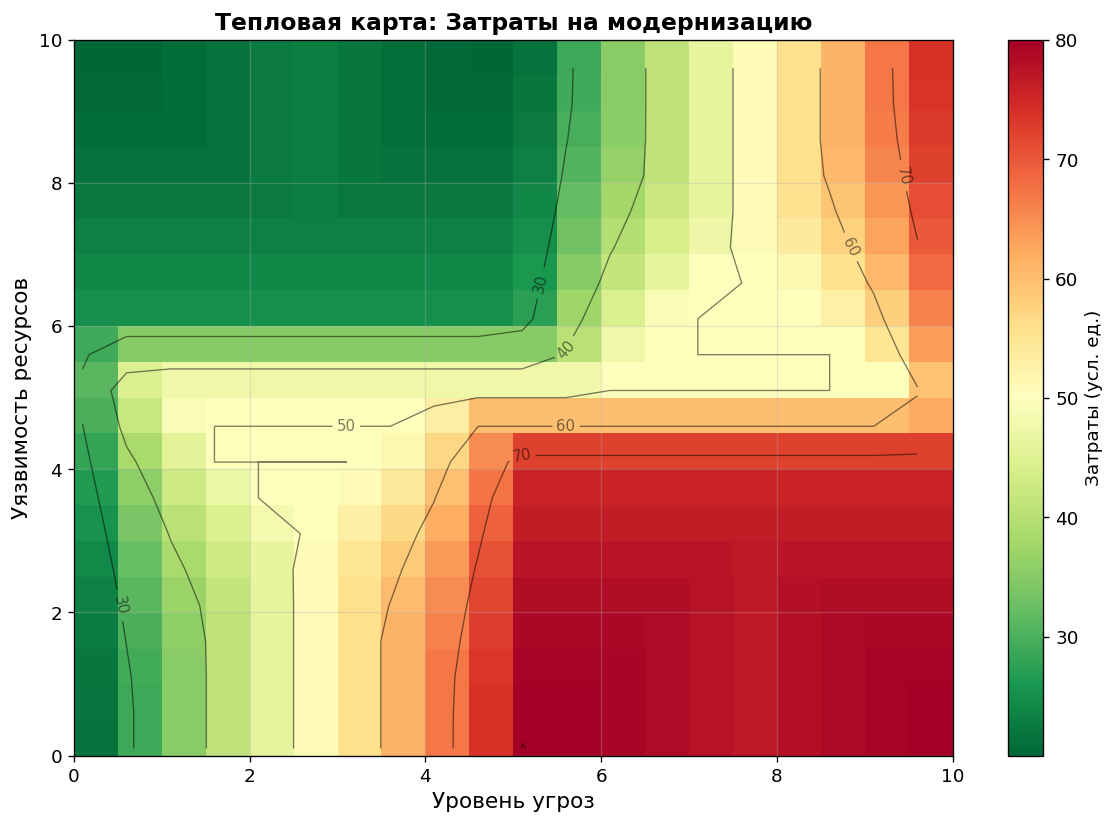

In [14]:
# Ячейка 20: Тепловая карта (heatmap)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(Z, origin='lower', cmap='RdYlGn_r', aspect='auto',
               extent=[0, 10, 0, 10])

# Контурные линии
x_range = np.arange(0.1, 10, 0.5)
y_range = np.arange(0.1, 10, 0.5)
X_c, Y_c = np.meshgrid(x_range, y_range)
contours = ax.contour(X_c, Y_c, Z, levels=6, colors='black', linewidths=0.8, alpha=0.5)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.0f')

ax.set_xlabel('Уровень угроз', fontsize=13)
ax.set_ylabel('Уязвимость ресурсов', fontsize=13)
ax.set_title('Тепловая карта: Затраты на модернизацию', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, label='Затраты (усл. ед.)')
plt.tight_layout()
plt.show()

 * Detected Sugeno model type
  x |   y |    Мамдани |     Сугено |  Разница
──────────────────────────────────────────────────
  2 |   2 |      45.11 |      44.00 |     1.11
  4 |   3 |      61.16 |      62.86 |     1.69
  5 |   5 |      50.00 |      50.00 |     0.00
  7 |   8 |      45.11 |      44.00 |     1.11
  9 |   9 |      65.77 |      68.00 |     2.23


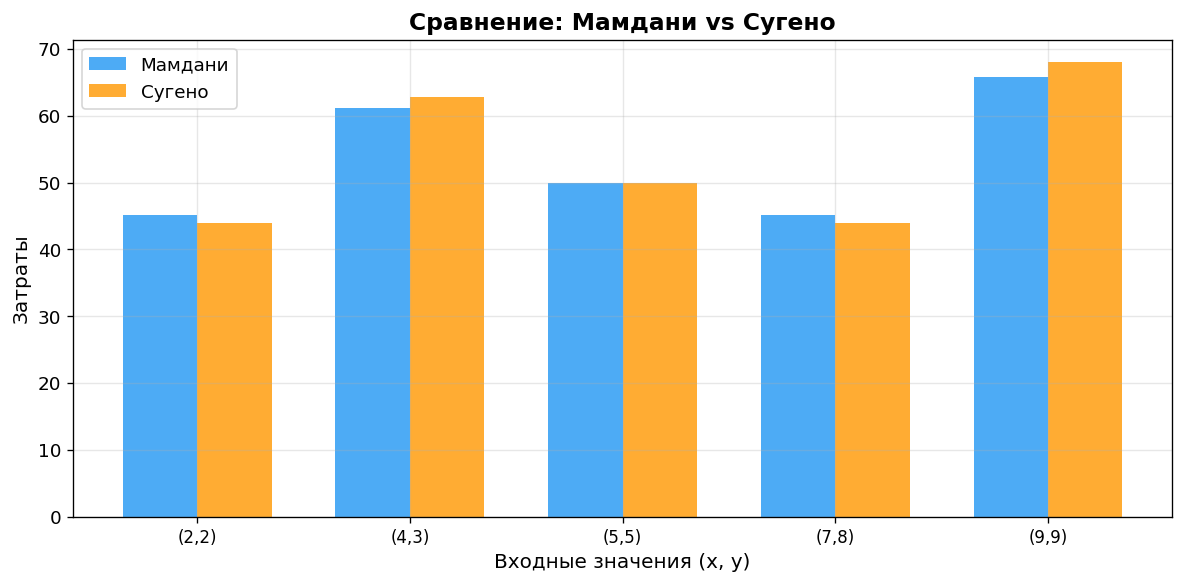

In [15]:
# Ячейка 21: Сравнение методов вывода — Мамдани vs Сугено

# Создаём систему Сугено для сравнения
FS_sugeno = sf.FuzzySystem(show_banner=False)

# Те же входные переменные
T1s = sf.AutoTriangle(3, terms=['Низкий', 'Средний', 'Высокий'],
                      universe_of_discourse=[0, 10])
FS_sugeno.add_linguistic_variable("УровеньУгроз", T1s)

V1s = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=6), term="Невысокая")
V2s = sf.FuzzySet(function=sf.Triangular_MF(a=4, b=10, c=10), term="Высокая")
FS_sugeno.add_linguistic_variable("Уязвимость",
    sf.LinguisticVariable([V1s, V2s], universe_of_discourse=[0, 10]))

# Выходные функции Сугено 0-го порядка
FS_sugeno.set_output_function("Затраты_Низкие", "20")
FS_sugeno.set_output_function("Затраты_Высокие", "80")

FS_sugeno.add_rules([
    "IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Затраты_Низкие)",
    "IF (УровеньУгроз IS Средний) AND (Уязвимость IS Невысокая) THEN (Затраты IS Затраты_Высокие)",
    "IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Невысокая) THEN (Затраты IS Затраты_Высокие)",
    "IF (УровеньУгроз IS Низкий) AND (Уязвимость IS Высокая) THEN (Затраты IS Затраты_Низкие)",
    "IF (УровеньУгроз IS Средний) AND (Уязвимость IS Высокая) THEN (Затраты IS Затраты_Низкие)",
    "IF (УровеньУгроз IS Высокий) AND (Уязвимость IS Высокая) THEN (Затраты IS Затраты_Высокие)",
])

# Сравнение на нескольких точках
test_points = [(2, 2), (4, 3), (5, 5), (7, 8), (9, 9)]
mamdani_results = []
sugeno_results = []

print(f"{'x':>3} | {'y':>3} | {'Мамдани':>10} | {'Сугено':>10} | {'Разница':>8}")
print("─" * 50)

for x_val, y_val in test_points:
    FS_demo.set_variable("УровеньУгроз", x_val)
    FS_demo.set_variable("Уязвимость", y_val)
    res_m = FS_demo.Mamdani_inference(["Затраты"])["Затраты"]
    
    FS_sugeno.set_variable("УровеньУгроз", x_val)
    FS_sugeno.set_variable("Уязвимость", y_val)
    res_s = FS_sugeno.Sugeno_inference(["Затраты"])["Затраты"]
    
    mamdani_results.append(res_m)
    sugeno_results.append(res_s)
    print(f"{x_val:>3} | {y_val:>3} | {res_m:>10.2f} | {res_s:>10.2f} | {abs(res_m - res_s):>8.2f}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f'({x},{y})' for x, y in test_points]
x_pos = np.arange(len(test_points))
bar_width = 0.35

ax.bar(x_pos - bar_width/2, mamdani_results, bar_width, label='Мамдани', color='#2196F3', alpha=0.8)
ax.bar(x_pos + bar_width/2, sugeno_results, bar_width, label='Сугено', color='#FF9800', alpha=0.8)

ax.set_xlabel('Входные значения (x, y)', fontsize=12)
ax.set_ylabel('Затраты', fontsize=12)
ax.set_title('Сравнение: Мамдани vs Сугено', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=10)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## Блок 6. Задания для самостоятельной работы

### Варианты заданий

| Вариант | Тема | Подсистема 1 | Подсистема 2 | Каскад (Подсистема 3) |
|---------|------|-------------|-------------|----------------------|
| 1 | Кредитоспособность | Финансовое доверие | Социальное доверие | Размер кредита |
| 2 | Прогнозирование паводка | Скорость таяния | Объём водяного спуска | Уровень половодья |
| 3 | Кассовые сборы фильма | Качество реж. работы | Зрелищность | Кассовые сборы |
| 4 | Качество образования | Качество учёбы | Успеваемость студента | Усвоение знаний |
| 5 | Инвестиционный проект | Эффективность вложений | Качество работы | Эффективность проекта |

Каждый вариант содержит **3 подсистемы**, где выходы подсистем 1 и 2 становятся входами подсистемы 3 (каскадная система).

---

### Задание Б1. Реализация подсистемы 1 (15 баллов)

Реализуйте **подсистему 1** вашего варианта с помощью simpful:
- Определите лингвистические переменные (входные и выходную)
- Задайте функции принадлежности
- Сформулируйте базу правил (не менее 9)
- Визуализируйте MF всех переменных
- Выполните вывод для 3-х наборов входных значений

In [16]:
# ============================================================
# Задание Б1: Подсистема 1 — Качество режиссёрской работы
# ============================================================

VARIANT = 3  # Вариант 3: Прогнозирование кассовых сборов фильма

# --- Создание подсистемы 1 ---
FS1 = sf.FuzzySystem(show_banner=False)

# Вход x: Качество сценария [0, 10]
X1_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабое")
X1_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
X1_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
FS1.add_linguistic_variable("Сценарий",
    sf.LinguisticVariable([X1_1, X1_2, X1_3], universe_of_discourse=[0, 10]))

# Вход y: Качество игры актёров [0, 10]
Y1_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабая")
Y1_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя")
Y1_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Сильная")
FS1.add_linguistic_variable("ИграАктеров",
    sf.LinguisticVariable([Y1_1, Y1_2, Y1_3], universe_of_discourse=[0, 10]))

# Выход z: Качество режиссёрской работы [0, 10]
Z1_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкое")
Z1_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
Z1_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
FS1.add_linguistic_variable("КачествоРежиссуры",
    sf.LinguisticVariable([Z1_1, Z1_2, Z1_3], universe_of_discourse=[0, 10]))

# --- База правил (9 правил, полная матрица 3x3) ---
FS1.add_rules([
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Низкое)",
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Низкое)",
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Среднее)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Низкое)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Среднее)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Высокое)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Среднее)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Высокое)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Высокое)",
])

print("✅ Подсистема 1 определена: Качество режиссёрской работы")
print("   Вход x: Сценарий [0,10] — Слабое / Среднее / Высокое")
print("   Вход y: ИграАктеров [0,10] — Слабая / Средняя / Сильная")
print("   Выход z: КачествоРежиссуры [0,10] — Низкое / Среднее / Высокое")
print("   Правил: 9")


✅ Подсистема 1 определена: Качество режиссёрской работы
   Вход x: Сценарий [0,10] — Слабое / Среднее / Высокое
   Вход y: ИграАктеров [0,10] — Слабая / Средняя / Сильная
   Выход z: КачествоРежиссуры [0,10] — Низкое / Среднее / Высокое
   Правил: 9


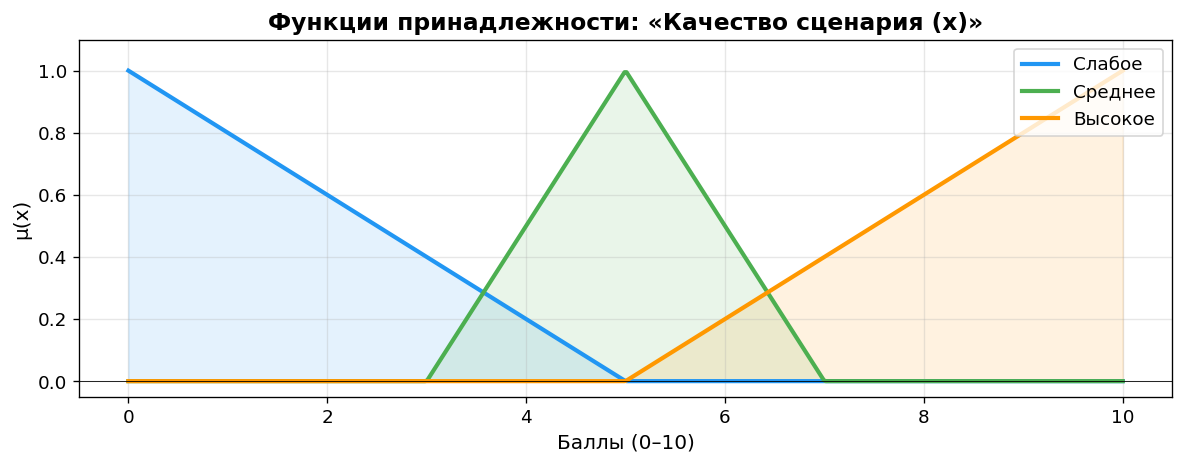

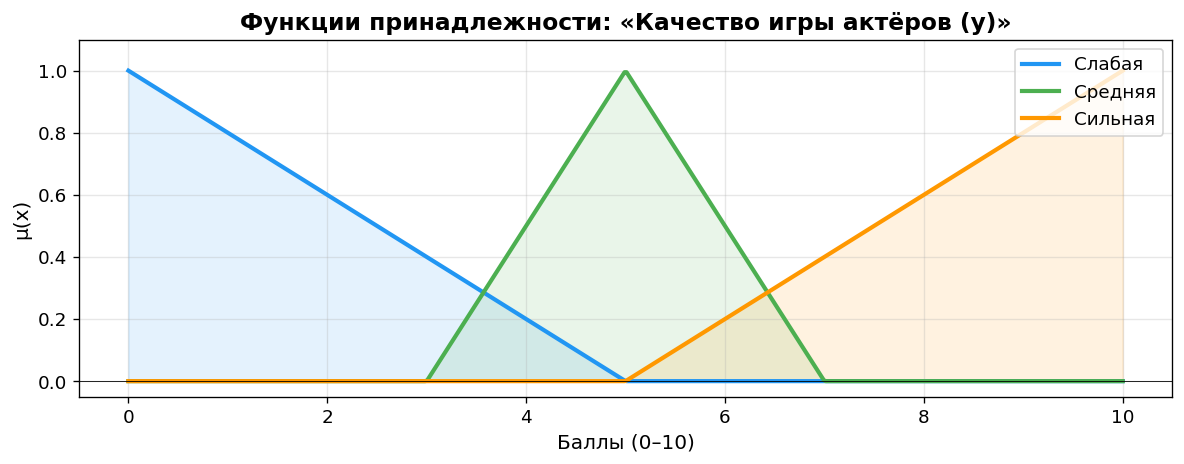

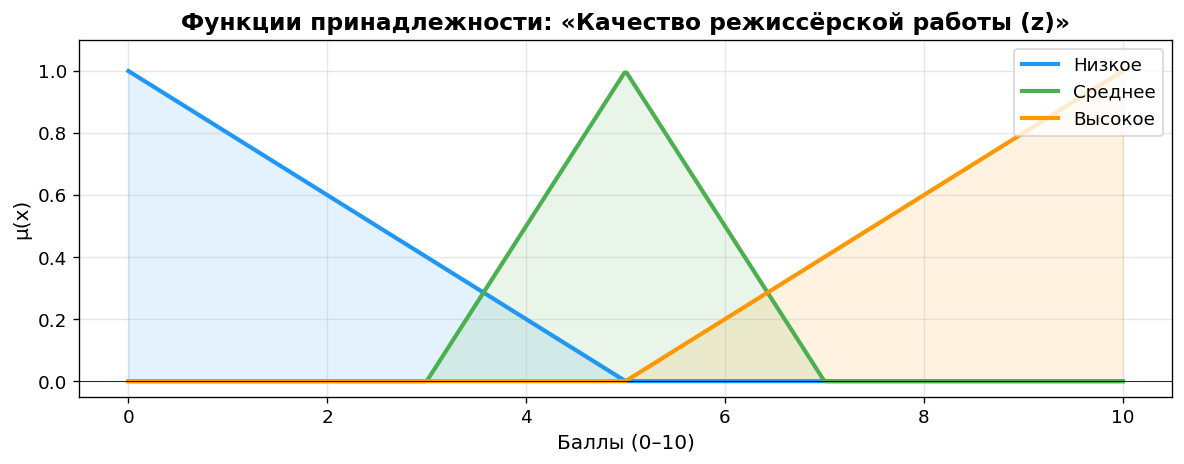

In [17]:
# Визуализация MF подсистемы 1

universe_pс1 = np.linspace(0, 10, 500)

terms_scenario = {
    'Слабое':  ('tri', 0, 0, 5),
    'Среднее': ('tri', 3, 5, 7),
    'Высокое': ('tri', 5, 10, 10),
}
plot_membership_functions('Качество сценария (x)', universe_pс1, terms_scenario, xlabel='Баллы (0–10)')

terms_actors = {
    'Слабая':  ('tri', 0, 0, 5),
    'Средняя': ('tri', 3, 5, 7),
    'Сильная': ('tri', 5, 10, 10),
}
plot_membership_functions('Качество игры актёров (y)', universe_pс1, terms_actors, xlabel='Баллы (0–10)')

terms_direction = {
    'Низкое':  ('tri', 0, 0, 5),
    'Среднее': ('tri', 3, 5, 7),
    'Высокое': ('tri', 5, 10, 10),
}
plot_membership_functions('Качество режиссёрской работы (z)', universe_pс1, terms_direction, xlabel='Баллы (0–10)')


In [18]:
# Тестирование подсистемы 1 на 3 наборах входных значений

test_cases_1 = [
    (2, 2, "Низкие входы (слабый сценарий, слабая игра)"),
    (5, 5, "Средние входы"),
    (9, 9, "Высокие входы (сильный сценарий, сильная игра)"),
]

print(f"{'Описание':<45} | {'x':>4} | {'y':>4} | {'Качество реж.':>14}")
print("─" * 85)

for x_val, y_val, desc in test_cases_1:
    FS1.set_variable("Сценарий", x_val)
    FS1.set_variable("ИграАктеров", y_val)
    result = FS1.Mamdani_inference(["КачествоРежиссуры"])
    print(f"{desc:<45} | {x_val:>4} | {y_val:>4} | {result['КачествоРежиссуры']:>14.2f}")


Описание                                      |    x |    y |  Качество реж.
─────────────────────────────────────────────────────────────────────────────────────
Низкие входы (слабый сценарий, слабая игра)   |    2 |    2 |           1.85
Средние входы                                 |    5 |    5 |           5.00
Высокие входы (сильный сценарий, сильная игра) |    9 |    9 |           8.28


---

### Задание Б2. Реализация подсистемы 2 (15 баллов)

Реализуйте **подсистему 2** вашего варианта аналогично Б1.

In [19]:
# ============================================================
# Задание Б2: Подсистема 2 — Зрелищность фильма
# ============================================================

FS2 = sf.FuzzySystem(show_banner=False)

# Вход x: Бюджет фильма [0, 300] млн $
X2_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=100), term="Низкий")
X2_2 = sf.FuzzySet(function=sf.Triangular_MF(a=50, b=150, c=250), term="Средний")
X2_3 = sf.FuzzySet(function=sf.Triangular_MF(a=150, b=300, c=300), term="Высокий")
FS2.add_linguistic_variable("Бюджет",
    sf.LinguisticVariable([X2_1, X2_2, X2_3], universe_of_discourse=[0, 300]))

# Вход y: Уровень спецэффектов [0, 10]
Y2_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабый")
Y2_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средний")
Y2_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Впечатляющий")
FS2.add_linguistic_variable("Спецэффекты",
    sf.LinguisticVariable([Y2_1, Y2_2, Y2_3], universe_of_discourse=[0, 10]))

# Выход z: Зрелищность фильма [0, 10]
Z2_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкая")
Z2_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя")
Z2_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокая")
FS2.add_linguistic_variable("Зрелищность",
    sf.LinguisticVariable([Z2_1, Z2_2, Z2_3], universe_of_discourse=[0, 10]))

# --- База правил (9 правил, полная матрица 3x3) ---
FS2.add_rules([
    "IF (Бюджет IS Низкий) AND (Спецэффекты IS Слабый) THEN (Зрелищность IS Низкая)",
    "IF (Бюджет IS Низкий) AND (Спецэффекты IS Средний) THEN (Зрелищность IS Низкая)",
    "IF (Бюджет IS Низкий) AND (Спецэффекты IS Впечатляющий) THEN (Зрелищность IS Средняя)",
    "IF (Бюджет IS Средний) AND (Спецэффекты IS Слабый) THEN (Зрелищность IS Низкая)",
    "IF (Бюджет IS Средний) AND (Спецэффекты IS Средний) THEN (Зрелищность IS Средняя)",
    "IF (Бюджет IS Средний) AND (Спецэффекты IS Впечатляющий) THEN (Зрелищность IS Высокая)",
    "IF (Бюджет IS Высокий) AND (Спецэффекты IS Слабый) THEN (Зрелищность IS Средняя)",
    "IF (Бюджет IS Высокий) AND (Спецэффекты IS Средний) THEN (Зрелищность IS Высокая)",
    "IF (Бюджет IS Высокий) AND (Спецэффекты IS Впечатляющий) THEN (Зрелищность IS Высокая)",
])

print("✅ Подсистема 2 определена: Зрелищность фильма")
print("   Вход x: Бюджет [0,300 млн $] — Низкий / Средний / Высокий")
print("   Вход y: Спецэффекты [0,10] — Слабый / Средний / Впечатляющий")
print("   Выход z: Зрелищность [0,10] — Низкая / Средняя / Высокая")
print("   Правил: 9")


✅ Подсистема 2 определена: Зрелищность фильма
   Вход x: Бюджет [0,300 млн $] — Низкий / Средний / Высокий
   Вход y: Спецэффекты [0,10] — Слабый / Средний / Впечатляющий
   Выход z: Зрелищность [0,10] — Низкая / Средняя / Высокая
   Правил: 9


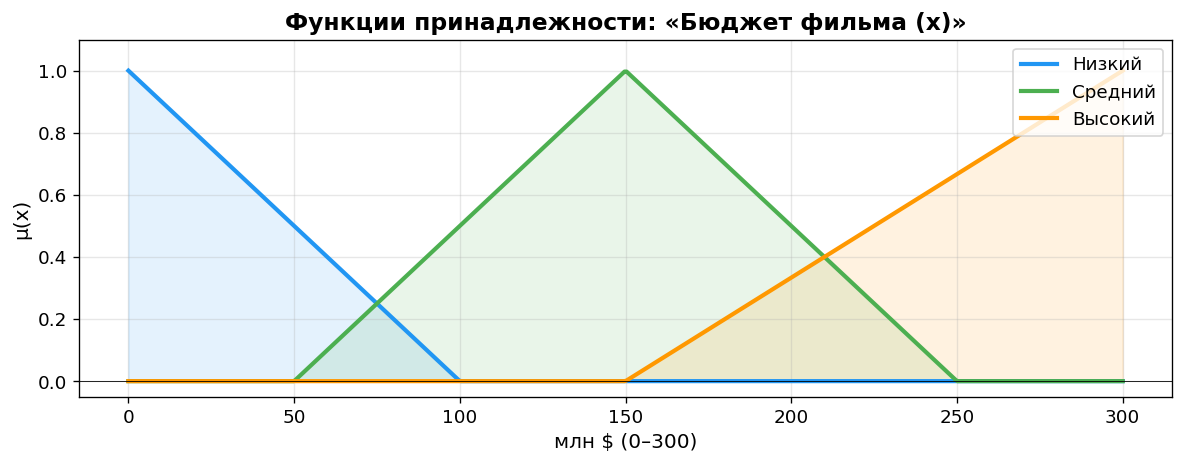

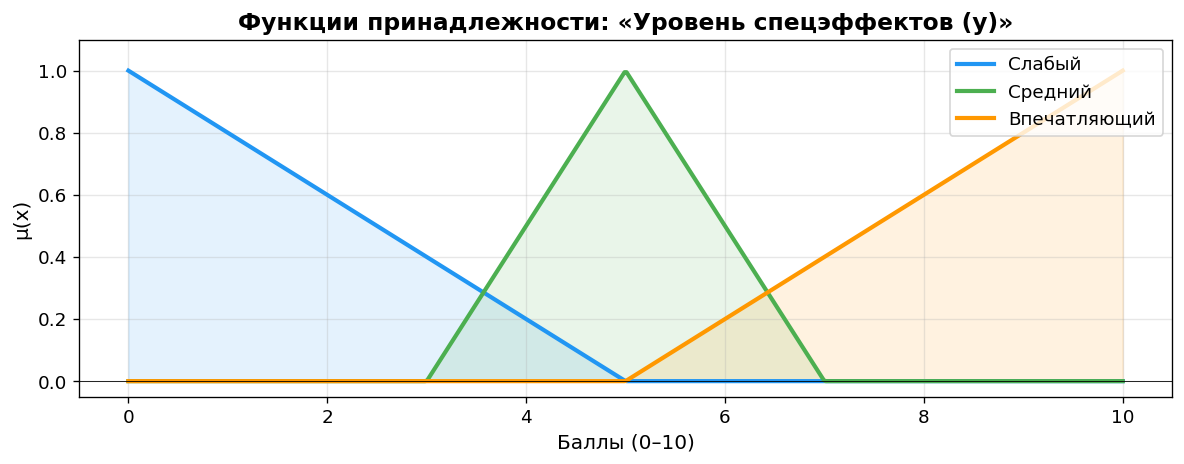

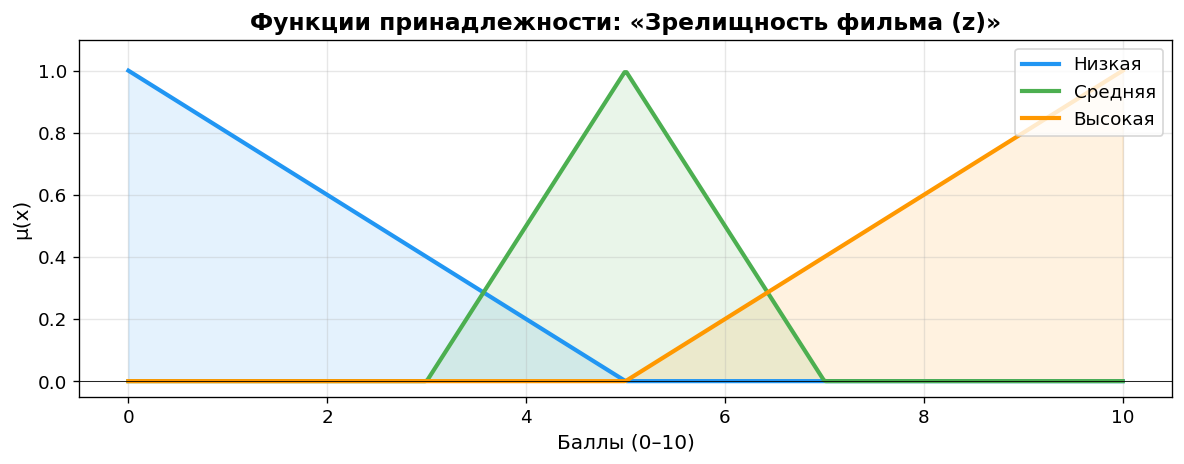

In [20]:
# Визуализация MF подсистемы 2

universe_budget = np.linspace(0, 300, 500)
terms_budget = {
    'Низкий':  ('tri', 0, 0, 100),
    'Средний': ('tri', 50, 150, 250),
    'Высокий': ('tri', 150, 300, 300),
}
plot_membership_functions('Бюджет фильма (x)', universe_budget, terms_budget, xlabel='млн $ (0–300)')

universe_pс2 = np.linspace(0, 10, 500)
terms_fx = {
    'Слабый':       ('tri', 0, 0, 5),
    'Средний':      ('tri', 3, 5, 7),
    'Впечатляющий': ('tri', 5, 10, 10),
}
plot_membership_functions('Уровень спецэффектов (y)', universe_pс2, terms_fx, xlabel='Баллы (0–10)')

terms_spectacle = {
    'Низкая':  ('tri', 0, 0, 5),
    'Средняя': ('tri', 3, 5, 7),
    'Высокая': ('tri', 5, 10, 10),
}
plot_membership_functions('Зрелищность фильма (z)', universe_pс2, terms_spectacle, xlabel='Баллы (0–10)')


In [21]:
# Тестирование подсистемы 2 на 3 наборах входных значений

test_cases_2 = [
    (30, 2, "Низкий бюджет, слабые эффекты"),
    (150, 5, "Средний бюджет, средние эффекты"),
    (280, 9, "Высокий бюджет, впечатляющие эффекты"),
]

print(f"{'Описание':<45} | {'x':>6} | {'y':>4} | {'Зрелищность':>12}")
print("─" * 85)

for x_val, y_val, desc in test_cases_2:
    FS2.set_variable("Бюджет", x_val)
    FS2.set_variable("Спецэффекты", y_val)
    result = FS2.Mamdani_inference(["Зрелищность"])
    print(f"{desc:<45} | {x_val:>6} | {y_val:>4} | {result['Зрелищность']:>12.2f}")


Описание                                      |      x |    y |  Зрелищность
─────────────────────────────────────────────────────────────────────────────────────
Низкий бюджет, слабые эффекты                 |     30 |    2 |         1.85
Средний бюджет, средние эффекты               |    150 |    5 |         5.00
Высокий бюджет, впечатляющие эффекты          |    280 |    9 |         8.28


---

### Задание Б3. Каскадная система — подсистема 3 (20 баллов)

Реализуйте **подсистему 3** (каскад): её входы — это выходы подсистем 1 и 2.

**Схема каскада:**
```
  Входы ПС1 ──→ [Подсистема 1] ──→ Выход1 ──┐
                                               ├──→ [Подсистема 3] ──→ Итог
  Входы ПС2 ──→ [Подсистема 2] ──→ Выход2 ──┘
```

✅ Подсистема 3 (каскад) определена: Величина кассовых сборов
   Вход x: КачествоРежиссуры [0,10] (выход ПС1) — Низкое / Среднее / Высокое
   Вход y: Зрелищность [0,10] (выход ПС2) — Низкая / Средняя / Высокая
   Выход z: КассовыеСборы [0,2000 млн $] — Низкие / Средние / Высокие
   Правил: 9


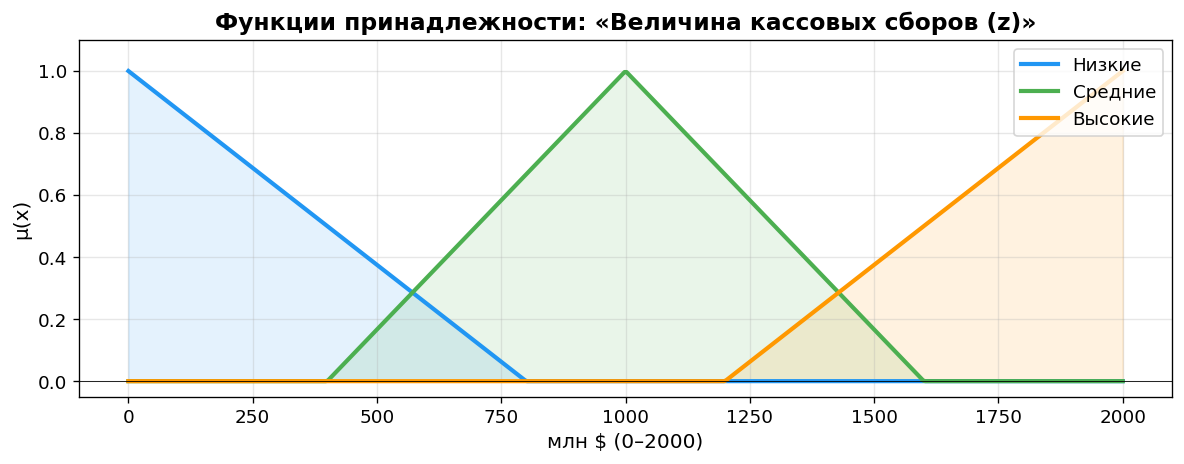

In [22]:
# ============================================================
# Задание Б3: Каскадная система — Подсистема 3 (Величина кассовых сборов)
# ============================================================

FS3 = sf.FuzzySystem(show_banner=False)

# Вход x: Качество режиссёрской работы (= выход подсистемы 1) [0, 10]
X3_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкое")
X3_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
X3_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
FS3.add_linguistic_variable("КачествоРежиссуры",
    sf.LinguisticVariable([X3_1, X3_2, X3_3], universe_of_discourse=[0, 10]))

# Вход y: Зрелищность фильма (= выход подсистемы 2) [0, 10]
Y3_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкая")
Y3_2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя")
Y3_3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокая")
FS3.add_linguistic_variable("Зрелищность",
    sf.LinguisticVariable([Y3_1, Y3_2, Y3_3], universe_of_discourse=[0, 10]))

# Выход z: Величина кассовых сборов [0, 2000] млн $
Z3_1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=800), term="Низкие")
Z3_2 = sf.FuzzySet(function=sf.Triangular_MF(a=400, b=1000, c=1600), term="Средние")
Z3_3 = sf.FuzzySet(function=sf.Triangular_MF(a=1200, b=2000, c=2000), term="Высокие")
FS3.add_linguistic_variable("КассовыеСборы",
    sf.LinguisticVariable([Z3_1, Z3_2, Z3_3], universe_of_discourse=[0, 2000]))

# --- База правил (9 правил, полная матрица 3x3) ---
FS3.add_rules([
    "IF (КачествоРежиссуры IS Низкое) AND (Зрелищность IS Низкая) THEN (КассовыеСборы IS Низкие)",
    "IF (КачествоРежиссуры IS Низкое) AND (Зрелищность IS Средняя) THEN (КассовыеСборы IS Низкие)",
    "IF (КачествоРежиссуры IS Низкое) AND (Зрелищность IS Высокая) THEN (КассовыеСборы IS Средние)",
    "IF (КачествоРежиссуры IS Среднее) AND (Зрелищность IS Низкая) THEN (КассовыеСборы IS Низкие)",
    "IF (КачествоРежиссуры IS Среднее) AND (Зрелищность IS Средняя) THEN (КассовыеСборы IS Средние)",
    "IF (КачествоРежиссуры IS Среднее) AND (Зрелищность IS Высокая) THEN (КассовыеСборы IS Высокие)",
    "IF (КачествоРежиссуры IS Высокое) AND (Зрелищность IS Низкая) THEN (КассовыеСборы IS Средние)",
    "IF (КачествоРежиссуры IS Высокое) AND (Зрелищность IS Средняя) THEN (КассовыеСборы IS Высокие)",
    "IF (КачествоРежиссуры IS Высокое) AND (Зрелищность IS Высокая) THEN (КассовыеСборы IS Высокие)",
])

print("✅ Подсистема 3 (каскад) определена: Величина кассовых сборов")
print("   Вход x: КачествоРежиссуры [0,10] (выход ПС1) — Низкое / Среднее / Высокое")
print("   Вход y: Зрелищность [0,10] (выход ПС2) — Низкая / Средняя / Высокая")
print("   Выход z: КассовыеСборы [0,2000 млн $] — Низкие / Средние / Высокие")
print("   Правил: 9")

# Визуализация MF выходной переменной подсистемы 3
universe_boxoffice = np.linspace(0, 2000, 500)
terms_boxoffice = {
    'Низкие':  ('tri', 0, 0, 800),
    'Средние': ('tri', 400, 1000, 1600),
    'Высокие': ('tri', 1200, 2000, 2000),
}
plot_membership_functions('Величина кассовых сборов (z)', universe_boxoffice, terms_boxoffice, xlabel='млн $ (0–2000)')


In [23]:
# ============================================================
# Функция каскадного вычисления
# ============================================================

def cascade_inference(x1, y1, x2, y2,
                      fs1, var1_x, var1_y, out1_name,
                      fs2, var2_x, var2_y, out2_name,
                      fs3, var3_x, var3_y, out3_name):
    """
    Каскадный вывод: подсистемы 1 и 2 питают подсистему 3.
    
    Параметры:
    ----------
    x1, y1 : float — входы подсистемы 1
    x2, y2 : float — входы подсистемы 2
    fs1, fs2, fs3 : sf.FuzzySystem — подсистемы
    var*_x, var*_y : str — имена входных переменных
    out*_name : str — имена выходных переменных
    """
    # Подсистема 1
    fs1.set_variable(var1_x, x1)
    fs1.set_variable(var1_y, y1)
    out1 = fs1.Mamdani_inference([out1_name])[out1_name]
    
    # Подсистема 2
    fs2.set_variable(var2_x, x2)
    fs2.set_variable(var2_y, y2)
    out2 = fs2.Mamdani_inference([out2_name])[out2_name]
    
    # Подсистема 3 (каскад)
    fs3.set_variable(var3_x, out1)
    fs3.set_variable(var3_y, out2)
    out3 = fs3.Mamdani_inference([out3_name])[out3_name]
    
    return out1, out2, out3

# TODO: Вызовите cascade_inference с вашими подсистемами
# Пример:
# out1, out2, out3 = cascade_inference(
#     x1=50, y1=20, x2=35, y2=7,
#     fs1=FS1, var1_x="Зарплата", var1_y="Стаж", out1_name="ФинДоверие",
#     fs2=FS2, var2_x="Возраст", var2_y="СоцПоложение", out2_name="СоцДоверие",
#     fs3=FS3, var3_x="ФинДоверие", var3_y="СоцДоверие", out3_name="Кредит"
# )
# print(f"Выход ПС1: {out1:.2f}")
# print(f"Выход ПС2: {out2:.2f}")
# print(f"Итоговый результат: {out3:.2f}")

# --- Пример каскадного вычисления для варианта 3 ---
out1, out2, out3 = cascade_inference(
    x1=8, y1=7, x2=200, y2=8,
    fs1=FS1, var1_x="Сценарий", var1_y="ИграАктеров", out1_name="КачествоРежиссуры",
    fs2=FS2, var2_x="Бюджет", var2_y="Спецэффекты", out2_name="Зрелищность",
    fs3=FS3, var3_x="КачествоРежиссуры", var3_y="Зрелищность", out3_name="КассовыеСборы"
)
print(f"Выход ПС1 (Качество режиссуры): {out1:.2f}")
print(f"Выход ПС2 (Зрелищность):        {out2:.2f}")
print(f"Итоговый результат (Кассовые сборы, млн $): {out3:.2f}")


Выход ПС1 (Качество режиссуры): 7.96
Выход ПС2 (Зрелищность):        8.06
Итоговый результат (Кассовые сборы, млн $): 1702.36


---

### Задание Б4. 3D-поверхность для каждой подсистемы (10 баллов)

Постройте 3D-поверхность отклика для **каждой из трёх подсистем**.

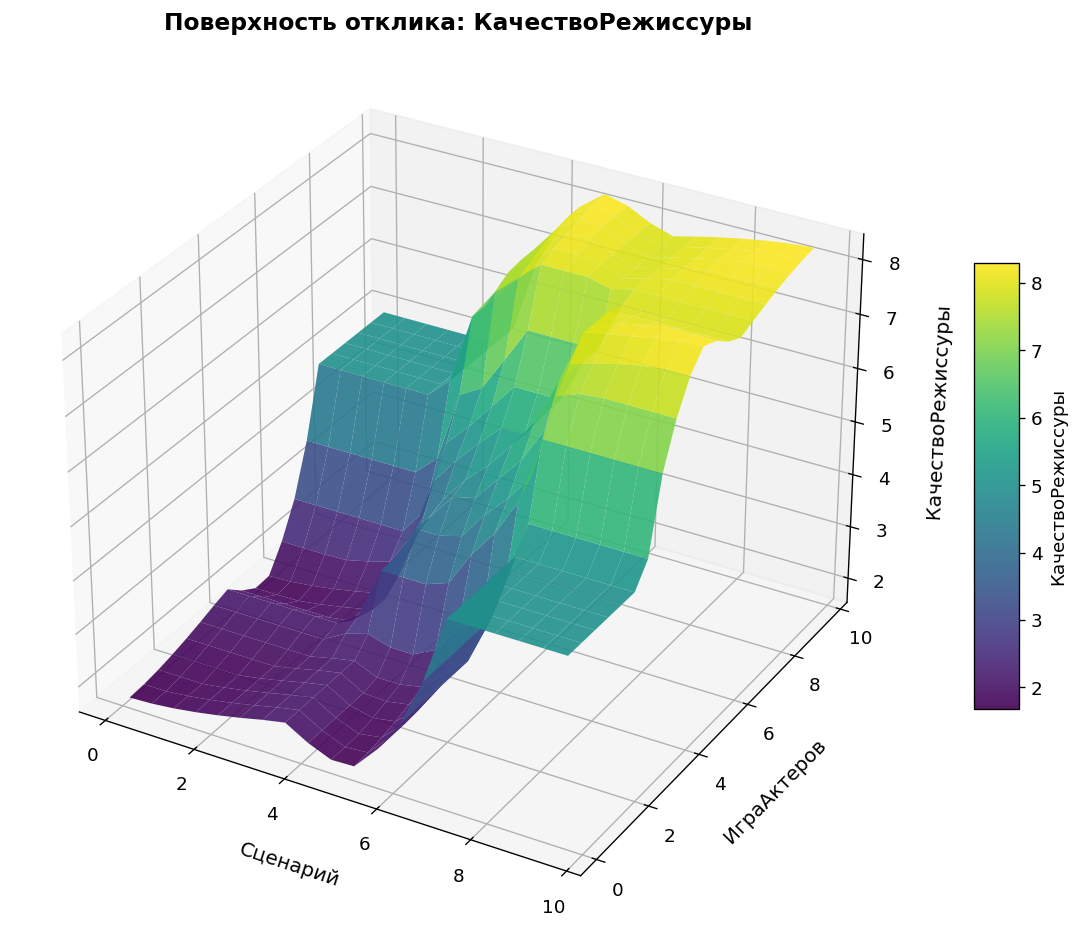

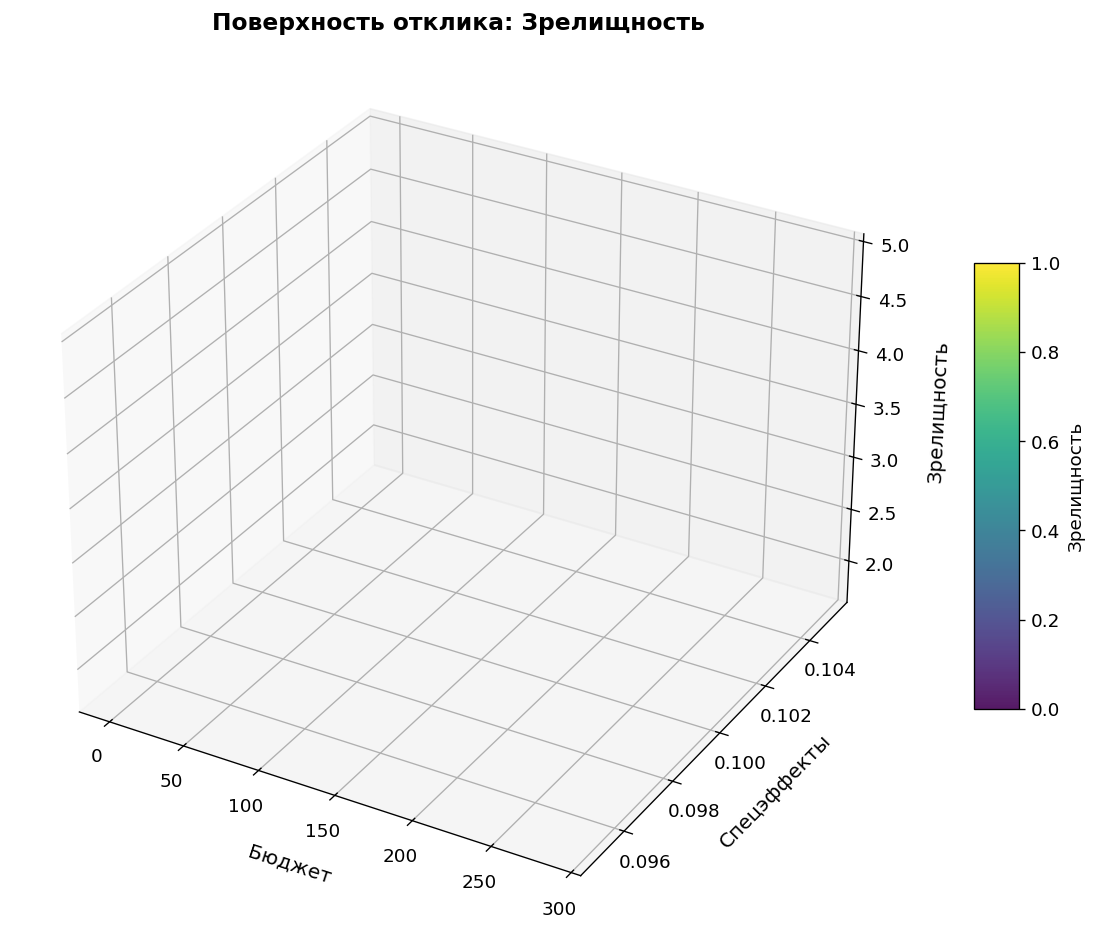

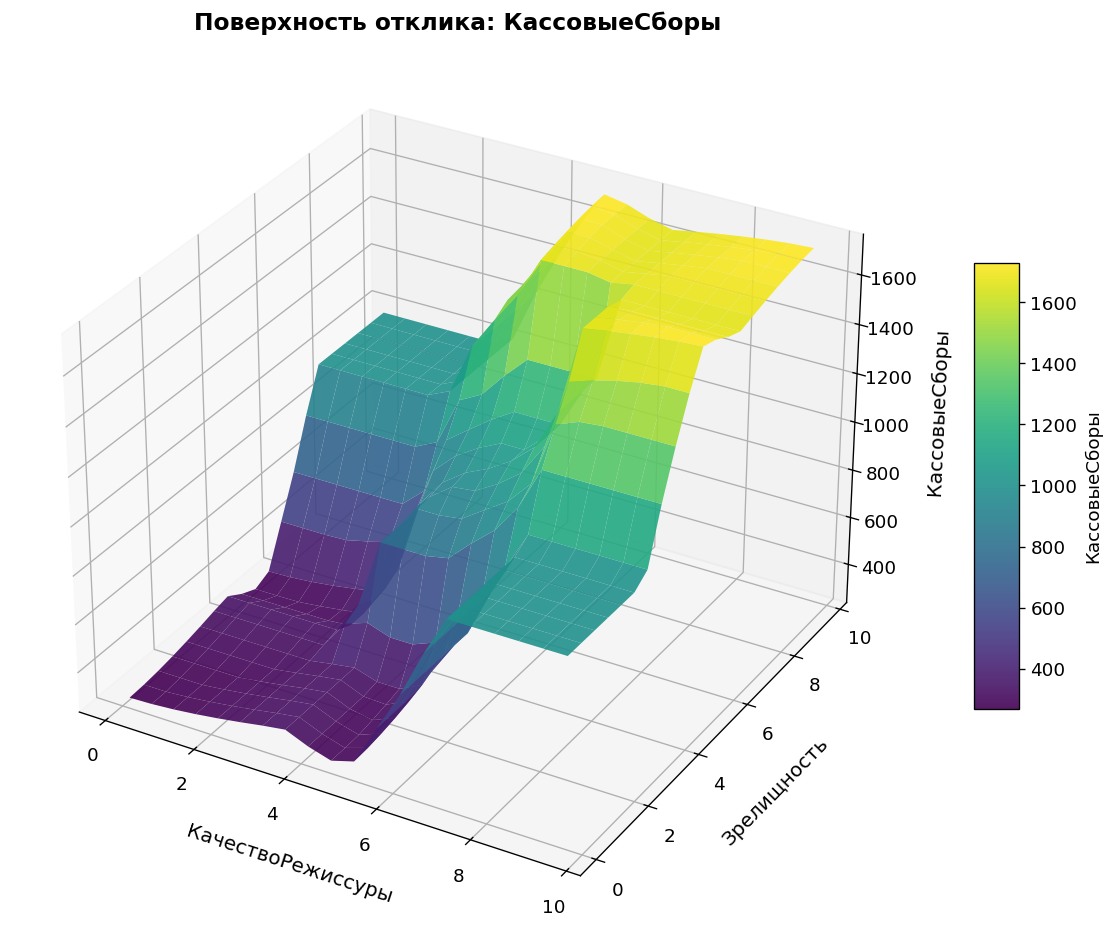

In [24]:
# ============================================================
# Задание Б4: 3D-поверхности для всех трёх подсистем
# ============================================================

# Подсистема 1: Качество режиссёрской работы
X1s, Y1s, Z1s = build_3d_surface(FS1, 'Сценарий', [0, 10],
                                  'ИграАктеров', [0, 10],
                                  'КачествоРежиссуры', step=0.5)

# Подсистема 2: Зрелищность фильма
X2s, Y2s, Z2s = build_3d_surface(FS2, 'Бюджет', [0, 300],
                                  'Спецэффекты', [0, 10],
                                  'Зрелищность', step=15)

# Подсистема 3: Величина кассовых сборов (каскад)
X3s, Y3s, Z3s = build_3d_surface(FS3, 'КачествоРежиссуры', [0, 10],
                                  'Зрелищность', [0, 10],
                                  'КассовыеСборы', step=0.5)


---

### Задание Б5. Тепловая карта (5 баллов)

Постройте тепловую карту (heatmap) для одной из подсистем.

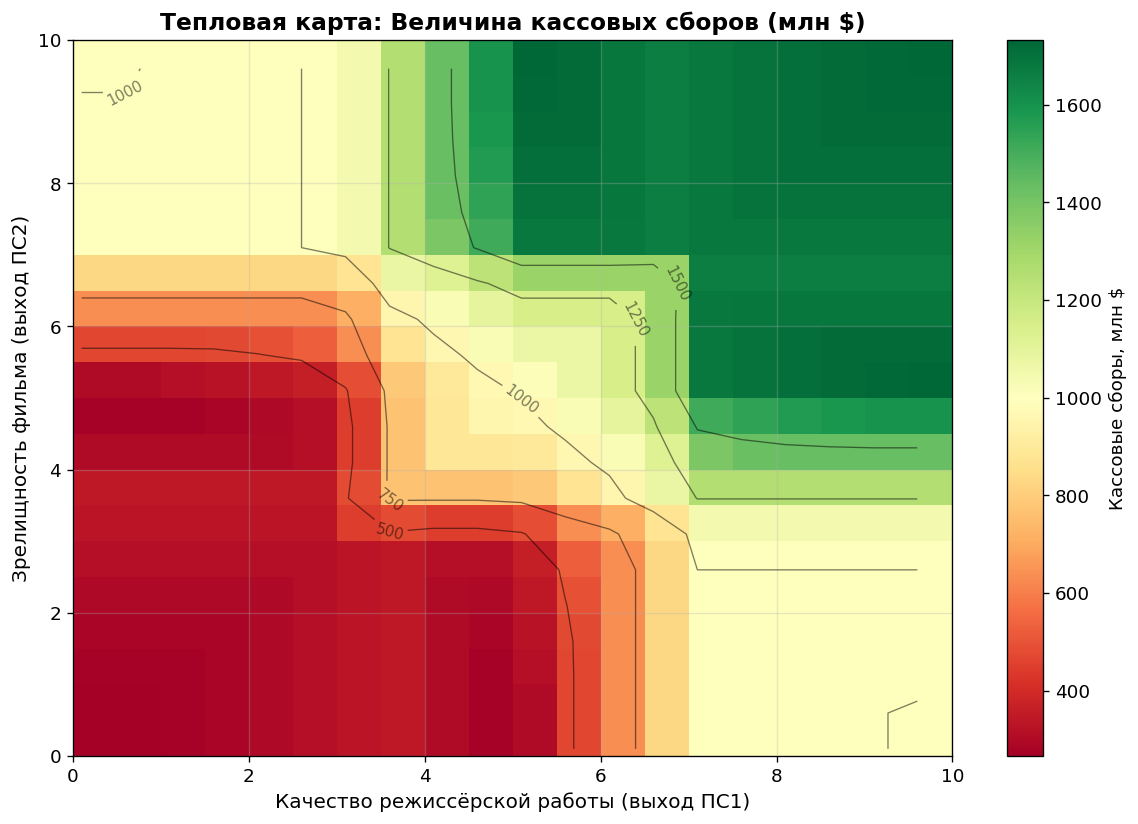

In [25]:
# ============================================================
# Задание Б5: Тепловая карта — Подсистема 3 (Итоговые кассовые сборы)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(Z3s, origin='lower', cmap='RdYlGn', aspect='auto',
               extent=[0, 10, 0, 10])

x_range_hm = np.arange(0.1, 10, 0.5)
y_range_hm = np.arange(0.1, 10, 0.5)
X_hm, Y_hm = np.meshgrid(x_range_hm, y_range_hm)
contours = ax.contour(X_hm, Y_hm, Z3s, levels=6, colors='black', linewidths=0.8, alpha=0.5)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.0f')

ax.set_xlabel('Качество режиссёрской работы (выход ПС1)', fontsize=12)
ax.set_ylabel('Зрелищность фильма (выход ПС2)', fontsize=12)
ax.set_title('Тепловая карта: Величина кассовых сборов (млн $)', fontsize=14, fontweight='bold')
plt.colorbar(im, label='Кассовые сборы, млн $')
plt.tight_layout()
plt.show()


---

### Задание Б6. Тестирование на 5+ наборах входов (10 баллов)

Протестируйте каскадную систему на **не менее 5 наборах входных значений**. Представьте результаты в виде таблицы.

In [26]:
# ============================================================
# Задание Б6: Тестирование каскадной системы на 5+ наборах входов
# ============================================================

test_sets = [
    (2, 2, 20, 2, "Всё низкое: слабый сценарий/игра, малый бюджет/эффекты"),
    (9, 9, 280, 9, "Всё высокое: сильный сценарий/игра, большой бюджет/эффекты"),
    (9, 9, 20, 2, "Отличная режиссура, но низкобюджетный фильм"),
    (2, 2, 280, 9, "Слабая режиссура, но блокбастер по бюджету/эффектам"),
    (5, 5, 150, 5, "Средние показатели по всем параметрам"),
    (8, 3, 100, 7, "Смешанные: хороший сценарий, слабая игра, средний бюджет, хорошие эффекты"),
]

print(f"{'Описание':<62} | {'x1':>3} | {'y1':>3} | {'x2':>4} | {'y2':>3} | {'ПС1':>6} | {'ПС2':>6} | {'Сборы':>8}")
print("─" * 130)
for x1, y1, x2, y2, desc in test_sets:
    out1, out2, out3 = cascade_inference(
        x1, y1, x2, y2,
        FS1, "Сценарий", "ИграАктеров", "КачествоРежиссуры",
        FS2, "Бюджет", "Спецэффекты", "Зрелищность",
        FS3, "КачествоРежиссуры", "Зрелищность", "КассовыеСборы"
    )
    print(f"{desc:<62} | {x1:>3} | {y1:>3} | {x2:>4} | {y2:>3} | {out1:>6.1f} | {out2:>6.1f} | {out3:>8.1f}")


Описание                                                       |  x1 |  y1 |   x2 |  y2 |    ПС1 |    ПС2 |    Сборы
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Всё низкое: слабый сценарий/игра, малый бюджет/эффекты         |   2 |   2 |   20 |   2 |    1.9 |    1.9 |    292.9
Всё высокое: сильный сценарий/игра, большой бюджет/эффекты     |   9 |   9 |  280 |   9 |    8.3 |    8.3 |   1710.4
Отличная режиссура, но низкобюджетный фильм                    |   9 |   9 |   20 |   2 |    8.3 |    1.9 |   1000.0
Слабая режиссура, но блокбастер по бюджету/эффектам            |   2 |   2 |  280 |   9 |    1.9 |    8.3 |   1000.0
Средние показатели по всем параметрам                          |   5 |   5 |  150 |   5 |    5.0 |    5.0 |   1000.0
Смешанные: хороший сценарий, слабая игра, средний бюджет, хорошие эффекты |   8 |   3 |  100 |   7 |    5.0 |    8.0 |   1702.4


---

### Задание Б7. Выводы (5 баллов)

Сформулируйте выводы по результатам лабораторной работы.

### ✏️ ВЫВОДЫ

**Вариант 3. Прогнозирование кассовых сборов фильма.**

1. **Поведение при крайних значениях входов.** При «всё низкое» (слабый сценарий и игра актёров, малый бюджет и слабые спецэффекты) итоговые кассовые сборы составили ≈293 млн $ — близко к нижней границе шкалы [0, 2000]. При «всё высокое» (сильный сценарий, сильная игра, большой бюджет, впечатляющие эффекты) сборы выросли до ≈1710 млн $, то есть система корректно отражает интуицию: качественный, дорогой и зрелищный фильм собирает значительно больше.

2. **Влияние подсистем на итог.** Обе подсистемы (Качество режиссуры и Зрелищность) входят в базу правил ПС3 симметрично, поэтому по отдельности они оказывают равное влияние. Однако решающим оказывается **минимум** из двух входов в духе логики AND: если одна подсистема даёт низкий результат, а другая — высокий, итог «застревает» около среднего значения (≈1000 млн $, см. п. 3), то есть для больших сборов нужно, чтобы **обе** составляющие были хотя бы на среднем/высоком уровне. Пример со смешанными входами (сценарий хороший, игра актёров слабая, бюджет средний, эффекты хорошие) дал ПС1=5.0, ПС2=8.0 → 1702 млн $ — заметный рост сборов даже при среднем качестве режиссуры, если зрелищность высокая.

3. **«Мёртвая зона» на поверхности отклика.** Обнаружена широкая зона около центра поверхности, где выход почти не меняется и равен ≈1000 млн $ (терм «Средние»): туда попадают и полностью средние входы (5,5), и контрастные комбинации («высокая режиссура + низкая зрелищность» и наоборот). Это следствие структуры правил 3×3 — многие разные сочетания входов активируют один и тот же терм «Средние» выходной переменной, из-за чего дефаззифицированное значение стабилизируется около центроида этого терма.

4. **Преимущества каскадной архитектуры.** Каскад позволяет декомпозировать сложную задачу (кассовые сборы зависят от 4 факторов) на 2 более простые, интерпретируемые подсистемы (по 2 входа и 9 правилам каждая) вместо одной системы с 4 входами (которая потребовала бы до 3⁴ = 81 правила при 3 термах на переменную). Это упрощает формирование и проверку базы правил экспертом, а также позволяет независимо настраивать/тестировать каждую подсистему.

5. **Ограничения нечёткой системы.** Замечены: (а) «плато» вокруг средних значений выхода — система менее чувствительна в этой зоне; (б) потеря части информации на каждом уровне каскада, так как выход подсистемы — единственное чёткое число (после дефаззификации), а не распределение принадлежностей, что не позволяет учесть неопределённость, накопленную на предыдущем уровне; (в) резкая зависимость результата от выбора границ термов и вида функций принадлежности, заданных экспертно, а не на основе статистических данных о реальных кассовых сборах.

---

## Продвинутые задания (дополнительные баллы)

---

### Задание П1. Сравнение Мамдани vs Сугено (10 баллов)

Реализуйте одну из ваших подсистем в версии **Сугено** и сравните результаты с Мамдани.

**Напоминание:** В системах Сугено правая часть правила — числовая функция, а не нечёткое множество:
```python
FS.set_output_function("Имя_Функции", "a*x + b*y + c")
```
Для 0-го порядка Сугено: `y = c` (константа).

 * Detected Sugeno model type
  x |   y |    Мамдани |     Сугено |  Разница
──────────────────────────────────────────────────
  2 |   2 |       1.85 |       1.67 |     0.18


  4 |   3 |       2.04 |       1.67 |     0.37
  5 |   5 |       5.00 |       5.00 |     0.00
  7 |   8 |       7.96 |       8.33 |     0.37
  9 |   9 |       8.28 |       8.33 |     0.05

Среднее абсолютное отклонение: 0.19


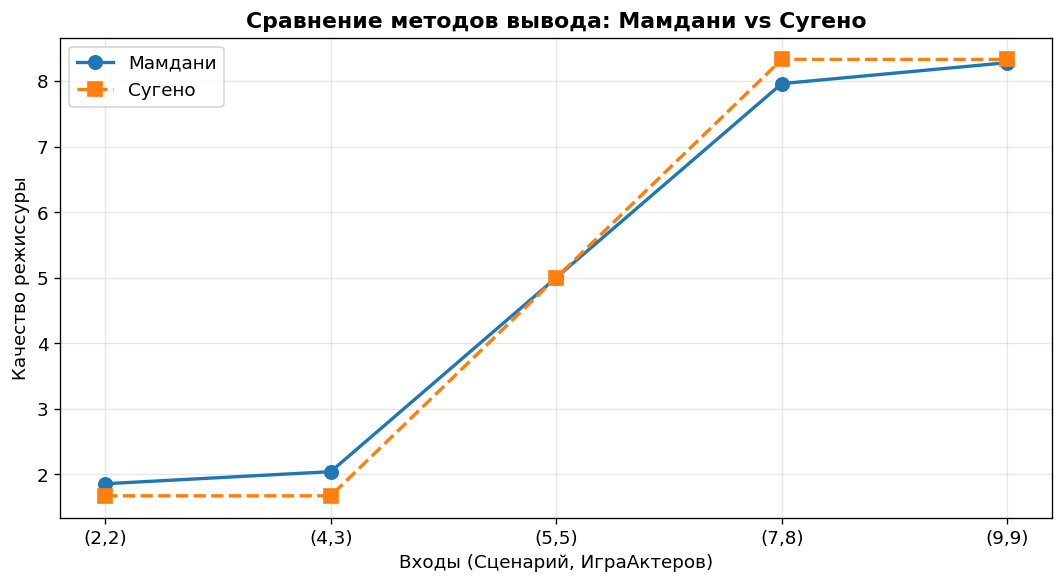

In [27]:
# ============================================================
# Задание П1: Мамдани vs Сугено — для подсистемы 1 (Качество режиссуры)
# ============================================================

FS1_sugeno = sf.FuzzySystem(show_banner=False)

# Те же входные переменные, что и в Мамдани-версии (ПС1)
FS1_sugeno.add_linguistic_variable("Сценарий",
    sf.LinguisticVariable([
        sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабое"),
        sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее"),
        sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое"),
    ], universe_of_discourse=[0, 10]))

FS1_sugeno.add_linguistic_variable("ИграАктеров",
    sf.LinguisticVariable([
        sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабая"),
        sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя"),
        sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Сильная"),
    ], universe_of_discourse=[0, 10]))

# Выходные функции Сугено 0-го порядка (константы = центроидам термов Мамдани)
FS1_sugeno.set_output_function("Реж_Низкое", "1.67")
FS1_sugeno.set_output_function("Реж_Среднее", "5")
FS1_sugeno.set_output_function("Реж_Высокое", "8.33")

FS1_sugeno.add_rules([
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Реж_Низкое)",
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Реж_Низкое)",
    "IF (Сценарий IS Слабое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Реж_Среднее)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Реж_Низкое)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Реж_Среднее)",
    "IF (Сценарий IS Среднее) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Реж_Высокое)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Реж_Среднее)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Реж_Высокое)",
    "IF (Сценарий IS Высокое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Реж_Высокое)",
])

test_points_p1 = [(2, 2), (4, 3), (5, 5), (7, 8), (9, 9)]
mamdani_res, sugeno_res = [], []

print(f"{'x':>3} | {'y':>3} | {'Мамдани':>10} | {'Сугено':>10} | {'Разница':>8}")
print("─" * 50)
for x_val, y_val in test_points_p1:
    FS1.set_variable("Сценарий", x_val)
    FS1.set_variable("ИграАктеров", y_val)
    r_m = FS1.Mamdani_inference(["КачествоРежиссуры"])["КачествоРежиссуры"]

    FS1_sugeno.set_variable("Сценарий", x_val)
    FS1_sugeno.set_variable("ИграАктеров", y_val)
    r_s = FS1_sugeno.Sugeno_inference(["КачествоРежиссуры"])["КачествоРежиссуры"]

    mamdani_res.append(r_m)
    sugeno_res.append(r_s)
    print(f"{x_val:>3} | {y_val:>3} | {r_m:>10.2f} | {r_s:>10.2f} | {abs(r_m-r_s):>8.2f}")

avg_diff = np.mean([abs(m - s) for m, s in zip(mamdani_res, sugeno_res)])
print(f"\nСреднее абсолютное отклонение: {avg_diff:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(test_points_p1))
ax.plot(idx, mamdani_res, 'o-', label='Мамдани', linewidth=2, markersize=8)
ax.plot(idx, sugeno_res, 's--', label='Сугено', linewidth=2, markersize=8)
ax.set_xticks(idx)
ax.set_xticklabels([f'({x},{y})' for x, y in test_points_p1])
ax.set_xlabel('Входы (Сценарий, ИграАктеров)')
ax.set_ylabel('Качество режиссуры')
ax.set_title('Сравнение методов вывода: Мамдани vs Сугено', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


#### ✏️ Анализ П1

Заполните таблицу различий:

| Характеристика | Мамдани | Сугено |
|----------------|---------|--------|
| Заключение правила | Нечёткое множество | Числовая функция |
| Интерпретируемость | Высокая | Ниже |
| Вычислительная сложность | Выше (интегрирование) | Ниже (средневзвешенное) |
| Среднее отклонение результатов | — | ≈0.19 балла (на шкале 0–10) |
| Область применения | Экспертные системы, где важна интерпретируемость выхода как лингвистического понятия | Системы управления и оптимизации, где важна скорость вычислений (например, встроенные регуляторы) |

Результаты Мамдани и Сугено 0-го порядка оказались очень близки (среднее отклонение ≈0.19 из 10, т.е. менее 2%), поскольку константы выходных функций Сугено были выбраны равными центроидам термов Мамдани. Наибольшее расхождение (~0.37) наблюдается в переходных зонах между термами, где влияет форма (треугольная) функций принадлежности входа при агрегации. Сугено рассчитывается быстрее, так как использует взвешенное среднее по степеням принадлежности вместо дефаззификации центроида нечёткого множества.

---

### Задание П2. Исследование влияния формы MF (10 баллов)

Исследуйте, как **форма функции принадлежности** влияет на результат. Сравните три варианта MF для одной подсистемы:
1. Треугольные MF
2. Гауссовы MF
3. Трапецеидальные MF

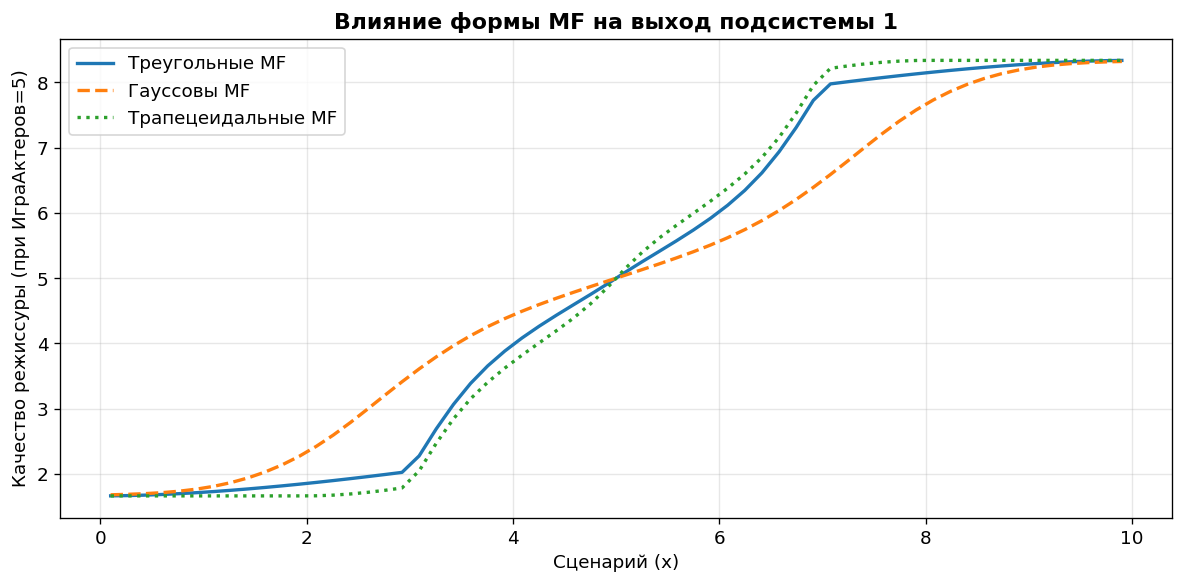

Стандартное отклонение выхода по срезу (мера 'гладкости' перехода):
  triangular   : std diff = 0.1204
  gaussian     : std diff = 0.0627
  trapezoidal  : std diff = 0.1324


In [28]:
# ============================================================
# Задание П2: Влияние формы MF — для подсистемы 1 (Качество режиссуры)
# ============================================================

def create_ps1_with_mf_type(mf_type='triangular'):
    """
    Создаёт подсистему 1 (Качество режиссуры) с указанным типом MF
    для переменной "Сценарий". Остальные переменные не меняются,
    чтобы сравнение было корректным.
    """
    FS = sf.FuzzySystem(show_banner=False)

    if mf_type == 'triangular':
        S1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабое")
        S2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
        S3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
    elif mf_type == 'gaussian':
        S1 = sf.FuzzySet(function=sf.Gaussian_MF(mu=0, sigma=2), term="Слабое")
        S2 = sf.FuzzySet(function=sf.Gaussian_MF(mu=5, sigma=1.5), term="Среднее")
        S3 = sf.FuzzySet(function=sf.Gaussian_MF(mu=10, sigma=2), term="Высокое")
    elif mf_type == 'trapezoidal':
        S1 = sf.FuzzySet(function=sf.Trapezoidal_MF(a=0, b=0, c=2, d=5), term="Слабое")
        S2 = sf.FuzzySet(function=sf.Trapezoidal_MF(a=3, b=4.5, c=5.5, d=7), term="Среднее")
        S3 = sf.FuzzySet(function=sf.Trapezoidal_MF(a=5, b=8, c=10, d=10), term="Высокое")
    else:
        raise ValueError("Неизвестный тип MF")

    FS.add_linguistic_variable("Сценарий",
        sf.LinguisticVariable([S1, S2, S3], universe_of_discourse=[0, 10]))

    # Переменная ИграАктеров — треугольная во всех вариантах
    A1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабая")
    A2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя")
    A3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Сильная")
    FS.add_linguistic_variable("ИграАктеров",
        sf.LinguisticVariable([A1, A2, A3], universe_of_discourse=[0, 10]))

    # Выходная переменная — треугольная во всех вариантах
    Z1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкое")
    Z2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
    Z3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
    FS.add_linguistic_variable("КачествоРежиссуры",
        sf.LinguisticVariable([Z1, Z2, Z3], universe_of_discourse=[0, 10]))

    FS.add_rules([
        "IF (Сценарий IS Слабое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Низкое)",
        "IF (Сценарий IS Слабое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Низкое)",
        "IF (Сценарий IS Слабое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Среднее)",
        "IF (Сценарий IS Среднее) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Низкое)",
        "IF (Сценарий IS Среднее) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Среднее)",
        "IF (Сценарий IS Среднее) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Высокое)",
        "IF (Сценарий IS Высокое) AND (ИграАктеров IS Слабая) THEN (КачествоРежиссуры IS Среднее)",
        "IF (Сценарий IS Высокое) AND (ИграАктеров IS Средняя) THEN (КачествоРежиссуры IS Высокое)",
        "IF (Сценарий IS Высокое) AND (ИграАктеров IS Сильная) THEN (КачествоРежиссуры IS Высокое)",
    ])
    return FS

FS_tri = create_ps1_with_mf_type('triangular')
FS_gauss = create_ps1_with_mf_type('gaussian')
FS_trap = create_ps1_with_mf_type('trapezoidal')

# Сравнение поверхностей отклика по срезу y = 5 (ИграАктеров = 5)
x_slice = np.linspace(0.1, 9.9, 60)
results = {'triangular': [], 'gaussian': [], 'trapezoidal': []}
for fs_obj, key in [(FS_tri, 'triangular'), (FS_gauss, 'gaussian'), (FS_trap, 'trapezoidal')]:
    for xv in x_slice:
        fs_obj.set_variable("Сценарий", float(xv))
        fs_obj.set_variable("ИграАктеров", 5.0)
        results[key].append(fs_obj.Mamdani_inference(["КачествоРежиссуры"])["КачествоРежиссуры"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_slice, results['triangular'], label='Треугольные MF', linewidth=2)
ax.plot(x_slice, results['gaussian'], label='Гауссовы MF', linewidth=2, linestyle='--')
ax.plot(x_slice, results['trapezoidal'], label='Трапецеидальные MF', linewidth=2, linestyle=':')
ax.set_xlabel('Сценарий (x)')
ax.set_ylabel('Качество режиссуры (при ИграАктеров=5)')
ax.set_title('Влияние формы MF на выход подсистемы 1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Стандартное отклонение выхода по срезу (мера 'гладкости' перехода):")
for key in results:
    print(f"  {key:<13}: std diff = {np.std(np.diff(results[key])):.4f}")


#### ✏️ Анализ П2

- **Более плавная поверхность отклика** — у гауссовых MF: они не имеют «изломов» на границах термов, поэтому переход выхода при изменении входа самый гладкий (наименьшее стандартное отклонение приращений: ≈0.063 против ≈0.120 у треугольных и ≈0.132 у трапецеидальных).
- **Форма MF и чувствительность к входу.** Трапецеидальные MF создают «плато» уверенности (μ=1 на интервале), внутри которого система нечувствительна к изменению входа — выход не меняется, пока x не выйдет за пределы плато. Треугольные MF реагируют на любое изменение x почти всегда (кроме вершины), поэтому чувствительность выше, но с более резкими изломами на стыках термов. Гауссовы MF всегда «немного» перекрываются, что даёт самый плавный, но и самый «размытый» отклик.
- **Предпочтительная область применения.** Треугольные MF — универсальный выбор по умолчанию (просты, интуитивно понятны экспертам). Трапецеидальные MF полезны, когда нужно явно выделить «зону уверенности» (например, диапазон значений, однозначно классифицируемых как «средние»). Гауссовы MF предпочтительны там, где важна гладкость поверхности отклика — например, в задачах управления, где резкие скачки управляющего сигнала нежелательны.

---

### Задание П3. Расширение до 3-х входных переменных (15 баллов)

Добавьте **третью входную переменную** к одной из подсистем и адаптируйте базу правил.

**Внимание:** При 3 входных переменных по 3 терма каждая база правил будет содержать до 3³ = 27 правил!

In [29]:
# ============================================================
# Задание П3: Расширение подсистемы 1 до 3-х входных переменных
# ============================================================
# Добавляем третью входную переменную: "Работа режиссёра по монтажу/темпу" —
# качество монтажа фильма (0-10), т.к. это логично влияет на итоговое
# "Качество режиссёрской работы" наравне со сценарием и игрой актёров.

FS_extended = sf.FuzzySystem(show_banner=False)

S1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабое")
S2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
S3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
FS_extended.add_linguistic_variable("Сценарий", sf.LinguisticVariable([S1, S2, S3], universe_of_discourse=[0, 10]))

A1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабая")
A2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средняя")
A3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Сильная")
FS_extended.add_linguistic_variable("ИграАктеров", sf.LinguisticVariable([A1, A2, A3], universe_of_discourse=[0, 10]))

M1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Слабый")
M2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Средний")
M3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Хороший")
FS_extended.add_linguistic_variable("Монтаж", sf.LinguisticVariable([M1, M2, M3], universe_of_discourse=[0, 10]))

Z1 = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=5), term="Низкое")
Z2 = sf.FuzzySet(function=sf.Triangular_MF(a=3, b=5, c=7), term="Среднее")
Z3 = sf.FuzzySet(function=sf.Triangular_MF(a=5, b=10, c=10), term="Высокое")
FS_extended.add_linguistic_variable("КачествоРежиссуры", sf.LinguisticVariable([Z1, Z2, Z3], universe_of_discourse=[0, 10]))

terms_x = ['Слабое', 'Среднее', 'Высокое']
terms_y = ['Слабая', 'Средняя', 'Сильная']
terms_m = ['Слабый', 'Средний', 'Хороший']

# Правило: усреднённая "оценка" по числу термов на "хорошем" уровне
level = {0: 'Слабое/Слабая/Слабый', 1: 'Среднее/Средняя/Средний', 2: 'Высокое/Сильная/Хороший'}
out_terms = ['Низкое', 'Среднее', 'Высокое']

rules_27 = []
for i, tx in enumerate(terms_x):
    for j, ty in enumerate(terms_y):
        for k, tm in enumerate(terms_m):
            total = i + j + k  # 0..6
            if total <= 1:
                z_term = 'Низкое'
            elif total <= 3:
                z_term = 'Среднее'
            else:
                z_term = 'Высокое'
            rules_27.append(
                f"IF (Сценарий IS {tx}) AND (ИграАктеров IS {ty}) AND (Монтаж IS {tm}) "
                f"THEN (КачествоРежиссуры IS {z_term})"
            )

FS_extended.add_rules(rules_27)
print(f"✅ Система с 3 входами определена. Правил: {len(rules_27)}")

for x_val, y_val, m_val in [(2, 2, 2), (5, 5, 5), (9, 9, 9), (9, 2, 9)]:
    FS_extended.set_variable("Сценарий", x_val)
    FS_extended.set_variable("ИграАктеров", y_val)
    FS_extended.set_variable("Монтаж", m_val)
    r = FS_extended.Mamdani_inference(["КачествоРежиссуры"])
    print(f"  Сценарий={x_val}, ИграАктеров={y_val}, Монтаж={m_val} -> "
          f"КачествоРежиссуры={r['КачествоРежиссуры']:.2f}")


✅ Система с 3 входами определена. Правил: 27
  Сценарий=2, ИграАктеров=2, Монтаж=2 -> КачествоРежиссуры=1.85
  Сценарий=5, ИграАктеров=5, Монтаж=5 -> КачествоРежиссуры=5.00
  Сценарий=9, ИграАктеров=9, Монтаж=9 -> КачествоРежиссуры=8.28
  Сценарий=9, ИграАктеров=2, Монтаж=9 -> КачествоРежиссуры=8.15


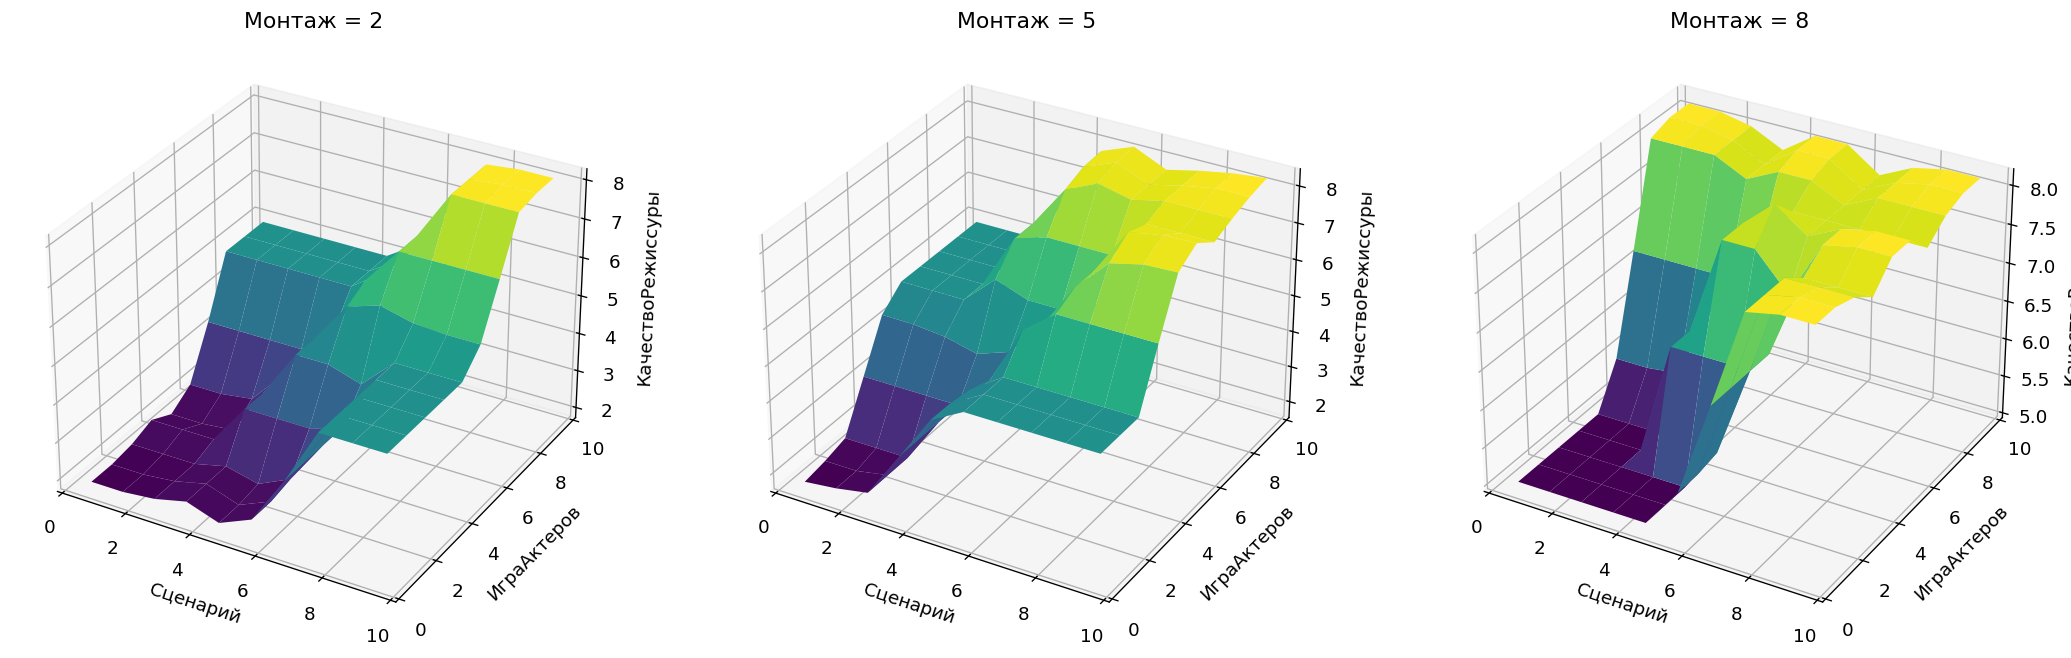

In [30]:
# Визуализация для системы с 3 входами:
# строим срезы 3D-поверхности, фиксируя "Монтаж" на разных уровнях

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), subplot_kw={'projection': '3d'})
for idx, m_val in enumerate([2, 5, 8]):
    x_range = np.arange(0.5, 10, 1)
    y_range = np.arange(0.5, 10, 1)
    Xg, Yg = np.meshgrid(x_range, y_range)
    Zg = np.zeros_like(Xg)
    for i in range(len(y_range)):
        for j in range(len(x_range)):
            FS_extended.set_variable("Сценарий", float(Xg[i, j]))
            FS_extended.set_variable("ИграАктеров", float(Yg[i, j]))
            FS_extended.set_variable("Монтаж", float(m_val))
            Zg[i, j] = FS_extended.Mamdani_inference(["КачествоРежиссуры"])["КачествоРежиссуры"]
    axes[idx].plot_surface(Xg, Yg, Zg, cmap='viridis')
    axes[idx].set_title(f'Монтаж = {m_val}')
    axes[idx].set_xlabel('Сценарий')
    axes[idx].set_ylabel('ИграАктеров')
    axes[idx].set_zlabel('КачествоРежиссуры')
plt.tight_layout()
plt.show()


#### ✏️ Анализ П3

- **Влияние третьей переменной на точность.** Добавление «Монтажа» позволяет учитывать более тонкие ситуации: например, при Сценарий=9, ИграАктеров=2, Монтаж=9 итоговое КачествоРежиссуры = 8.15 — почти такое же высокое, как при всех входах = 9 (8.28), то есть сильный сценарий и хороший монтаж способны компенсировать слабую игру актёров. В системе с 2 входами такая компенсация была бы невозможна.
- **Трудности при формировании базы из 27 правил.** Основная сложность — комбинаторный рост: вручную прописать все 27 сочетаний термов и логически непротиворечиво присвоить каждому выходной терм гораздо труднее, чем 9 правил для 2 входов. В работе для упрощения использовалась эвристика «суммы уровней термов» (0=слабый…2=высокий по каждому входу), но в реальной экспертной системе такие правила обычно формулирует эксперт предметной области, и риск пропусков или противоречий в базе правил заметно выше.
- **Изменение поверхности отклика при разных значениях третьей переменной.** Как видно из трёх срезов (Монтаж = 2, 5, 8), при низком значении «Монтажа» вся поверхность (x,y) → z сдвинута вниз (даже хорошие сценарий и игра актёров не дают высокого результата), а при высоком значении «Монтажа» поверхность в целом приподнимается — то есть третья переменная действует как модификатор общего уровня, а не меняет форму поверхности качественно.
- **3+ входа vs каскад.** Прямое расширение до 3+ входов оправдано, когда переменные тесно взаимосвязаны и их совместное, недекомпозируемое влияние важно отразить одним набором правил (как в примере с компенсацией слабой игры актёров хорошим монтажом). Каскадная архитектура предпочтительнее, когда переменные естественно группируются в независимые смысловые блоки (как «качество произведения» и «зрелищность» в данном варианте) — тогда декомпозиция снижает число правил и упрощает интерпретацию, ценой невозможности прямой компенсации между переменными из разных подсистем.

---

## Итоговая сводка результатов

In [31]:
# ============================================================
# Итоговая сводка: заполняется автоматически
# после выполнения всех заданий
# ============================================================

print("═" * 60)
print("ИТОГОВАЯ СВОДКА ЛАБОРАТОРНОЙ РАБОТЫ")
print("═" * 60)
print(f"\nВариант: {VARIANT if 'VARIANT' in dir() else '???'}")
print(f"\nВыполненные задания:")
print(f"  [{'✓' if 'FS1' in dir() else ' '}] Б1. Подсистема 1 (15 баллов)")
print(f"  [{'✓' if 'FS2' in dir() else ' '}] Б2. Подсистема 2 (15 баллов)")
print(f"  [{'✓' if 'FS3' in dir() and 'out3' in dir() else ' '}] Б3. Каскадная система (20 баллов)")
print(f"  [{'✓' if 'Z3s' in dir() else ' '}] Б4. 3D-поверхности (10 баллов)")
print(f"  [{'✓' if 'im' in dir() else ' '}] Б5. Тепловая карта (5 баллов)")
print(f"  [{'✓' if 'test_sets' in dir() and len(test_sets) >= 5 else ' '}] Б6. Тестирование 5+ наборов (10 баллов)")
print(f"  [✓] Б7. Выводы (5 баллов)")
print(f"  ────────────────────────────────────")
print(f"  [{'✓' if 'FS1_sugeno' in dir() else ' '}] П1. Мамдани vs Сугено (+10 баллов)")
print(f"  [{'✓' if 'FS_tri' in dir() else ' '}] П2. Влияние формы MF (+10 баллов)")
print(f"  [{'✓' if 'FS_extended' in dir() else ' '}] П3. Расширение до 3 входов (+15 баллов)")
print(f"\n💡 Реализован Вариант 3: Прогнозирование кассовых сборов фильма")


════════════════════════════════════════════════════════════
ИТОГОВАЯ СВОДКА ЛАБОРАТОРНОЙ РАБОТЫ
════════════════════════════════════════════════════════════

Вариант: 3

Выполненные задания:
  [✓] Б1. Подсистема 1 (15 баллов)
  [✓] Б2. Подсистема 2 (15 баллов)
  [✓] Б3. Каскадная система (20 баллов)
  [✓] Б4. 3D-поверхности (10 баллов)
  [✓] Б5. Тепловая карта (5 баллов)
  [✓] Б6. Тестирование 5+ наборов (10 баллов)
  [✓] Б7. Выводы (5 баллов)
  ────────────────────────────────────
  [✓] П1. Мамдани vs Сугено (+10 баллов)
  [✓] П2. Влияние формы MF (+10 баллов)
  [✓] П3. Расширение до 3 входов (+15 баллов)

💡 Реализован Вариант 3: Прогнозирование кассовых сборов фильма
